# 01 · Análisis Exploratorio de Datos (EDA)
## Recaudo de Rentas Cedidas del SGSS — Colombia, Oct 2021 – Dic 2025

> **Objetivo.** Realizar una exploración estadística rigurosa de la serie de recaudo
> de rentas cedidas para salud, con el fin de: *(i)* auditar la calidad de los datos,
> *(ii)* caracterizar la estructura categórica y temporal del ingreso fiscal,
> *(iii)* identificar componentes de tendencia, estacionalidad y ruido, y
> *(iv)* establecer las hipótesis estadísticas que guiarán la selección de modelos
> predictivos en las etapas subsiguientes.

**Metodología.** El análisis sigue un protocolo de EDA inspirado en Tukey (1977) y
Cleveland (1993), articulado en cuatro fases:

| Fase | Contenido |
|------|-----------|
| **I** | Auditoría de calidad, tipificación y estructura categórica |
| **II** | Agregación mensual, tendencia visual, estacionalidad |
| **III** | Descomposición clásica, estacionariedad (ADF/KPSS), ACF/PACF |
| **IV** | Deflación real con IPC, crecimiento interanual, correlación macro |

**Dataset.** `BaseRentasCedidasVF.xlsx` — 149 648 registros
transaccionales × 13 variables, periodo Oct 2021 – Dic 2025 (51 meses).


In [11]:
# ── 0. Configuración centralizada ─────────────────────────────────
import pandas as pd
import numpy as np
%run 00_config.py

# Librerías adicionales para EDA avanzado
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import calendar

print(f"\n📁 Archivo de datos: {DATA_FILE.name}")
print(f"📊 Variables macro cargadas: {sorted(MACRO_DATA.keys())}")
print(f"🔧 Periodo: {FECHA_INICIO} → {FECHA_FIN}")
print(f"✂️  División Entrenamiento/Prueba: Entrenamiento hasta {TRAIN_END} | Prueba desde {TEST_START}")


Config cargada -- Datos: BaseRentasCedidasVF.xlsx | Periodo: 2021-10-01 a 2025-12-31
  Tema profesional activo -- DPI 300, tipografia serif, paleta academica

📁 Archivo de datos: BaseRentasCedidasVF.xlsx
📊 Variables macro cargadas: [2021, 2022, 2023, 2024, 2025, 2026]
🔧 Periodo: 2021-10-01 → 2025-12-31
✂️  División Entrenamiento/Prueba: Entrenamiento hasta 2025-09-30 | Prueba desde 2025-10-01


---
## Fase I — Auditoría de Calidad y Estructura de Datos
### 1.1  Carga y perfilamiento inicial

Se importa el archivo fuente y se realiza un perfilamiento automático que incluye:
dimensiones, tipos de dato, nulos, rango temporal y conteo de valores únicos por columna.


In [12]:
# ── 1.1 Carga del dataset ─────────────────────────────────────────
print(f"Cargando: {DATA_FILE.name}")
df = pd.read_excel(DATA_FILE)
print(f"✅ Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas\n")

# Perfilamiento completo
print("═" * 70)
print("PERFIL DEL DATASET")
print("═" * 70)
print(f"{'Columna':<35} {'Tipo':<18} {'Nulos':>6} {'Únicos':>8}")
print("─" * 70)
for col in df.columns:
    n_nulos = df[col].isna().sum()
    n_unicos = df[col].nunique()
    dtype = str(df[col].dtype)
    marca = " ⚠️" if n_nulos > 0 else ""
    print(f"{col:<35} {dtype:<18} {n_nulos:>6,} {n_unicos:>8,}{marca}")

print(f"\n📅 Rango temporal: {df[COL_FECHA].min()} → {df[COL_FECHA].max()}")
print(f"📊 Meses únicos:  {df[COL_FECHA].dt.to_period('M').nunique()}")


Cargando: BaseRentasCedidasVF.xlsx
✅ Dimensiones: 149,648 filas × 13 columnas

══════════════════════════════════════════════════════════════════════
PERFIL DEL DATASET
══════════════════════════════════════════════════════════════════════
Columna                             Tipo                Nulos   Únicos
──────────────────────────────────────────────────────────────────────
FechaRecaudo                        datetime64[ns]          0    1,048
NitBeneficiarioAportante            int64                   0    1,180
NombreBeneficiarioAportante         object                  0    1,143
ValorRecaudo                        object                  0  140,155
Nombre de Rubro                     object                  0        4
NombreGrupoFuente                   object                  0        2
CódigoSubGrupoFuente                int64                   0       10
NombreSubGrupoFuente                object                  0       10
CódigoConcepto                      object        

### 1.2  Conversión de tipos y detección de anomalías

`ValorRecaudo` se almacena como *object* (texto) en el archivo fuente;
se convierte a numérico forzando `errors='coerce'` para detectar entradas
no parseables. Se documentan los registros con valor negativo, que corresponden
mayoritariamente a **ajustes contables presupuestales** — un mecanismo
legítimo de conciliación fiscal.


In [13]:
# ── 1.2 Conversiones y limpieza ───────────────────────────────────
# Fecha → datetime
df[COL_FECHA] = pd.to_datetime(df[COL_FECHA])

# Valor → numérico (viene como string)
df[COL_VALOR] = pd.to_numeric(df[COL_VALOR], errors='coerce')
n_coerced = df[COL_VALOR].isna().sum()
if n_coerced > 0:
    print(f"⚠️ {n_coerced} valores no numéricos convertidos a NaN — se eliminan.")
    df = df.dropna(subset=[COL_VALOR])

# Valores negativos
mask_neg = df[COL_VALOR] < 0
neg = df[mask_neg]
print(f"\n{'═' * 60}")
print(f"DIAGNÓSTICO DE VALORES NEGATIVOS")
print(f"{'═' * 60}")
print(f"Total registros negativos: {len(neg):,}")
print(f"Suma de negativos:         ${neg[COL_VALOR].sum():,.0f}")
print(f"\nDistribución por TipoRegistro:")
print(neg['TipoRegistro'].value_counts().to_string())
print(f"\nDistribución por NombreSubGrupoFuente:")
print(neg['NombreSubGrupoFuente'].value_counts().to_string())
print(f"\n✅ Los valores negativos se MANTIENEN: representan la dinámica fiscal neta.")

# Índice temporal
df.set_index(COL_FECHA, inplace=True)
df.sort_index(inplace=True)
print(f"\n📅 Índice temporal establecido: {df.index.min():%Y-%m-%d} → {df.index.max():%Y-%m-%d}")
print(f"📊 Registros finales: {len(df):,}")


⚠️ 3 valores no numéricos convertidos a NaN — se eliminan.

════════════════════════════════════════════════════════════
DIAGNÓSTICO DE VALORES NEGATIVOS
════════════════════════════════════════════════════════════
Total registros negativos: 27
Suma de negativos:         $-829,257,705

Distribución por TipoRegistro:
TipoRegistro
Ajuste Contable - Presupuestal    26
Recaudo                            1

Distribución por NombreSubGrupoFuente:
NombreSubGrupoFuente
Rendimientos Sobre Recursos Entregados en Administración        15
Otros Recursos Propios Destinados al Aseguramiento               3
Monopolio de Juegos de Suerte y Azar Entidades Territoriales     3
COLJUEGOS para Régimen Subsidiado                                2
Ajuste Contable - Presupuestal                                   2
Ad Valorem Impuesto Consumo Cigarrillo y Tabacos                 1
Impoconsumo Licores, Vinos, Aperitivos y Similares               1

✅ Los valores negativos se MANTIENEN: representan la dinámica fi

### 1.3  Estructura categórica del recaudo

Se explora la composición del dataset por sus dimensiones cualitativas:
**Rubro**, **Grupo/SubGrupo Fuente**, **Tipo de Registro** y **SubGrupo Aportante**.
Esta taxonomía es fundamental para segmentar el análisis predictivo posterior.


  📊 Figura guardada: 01_composicion_categorica.png


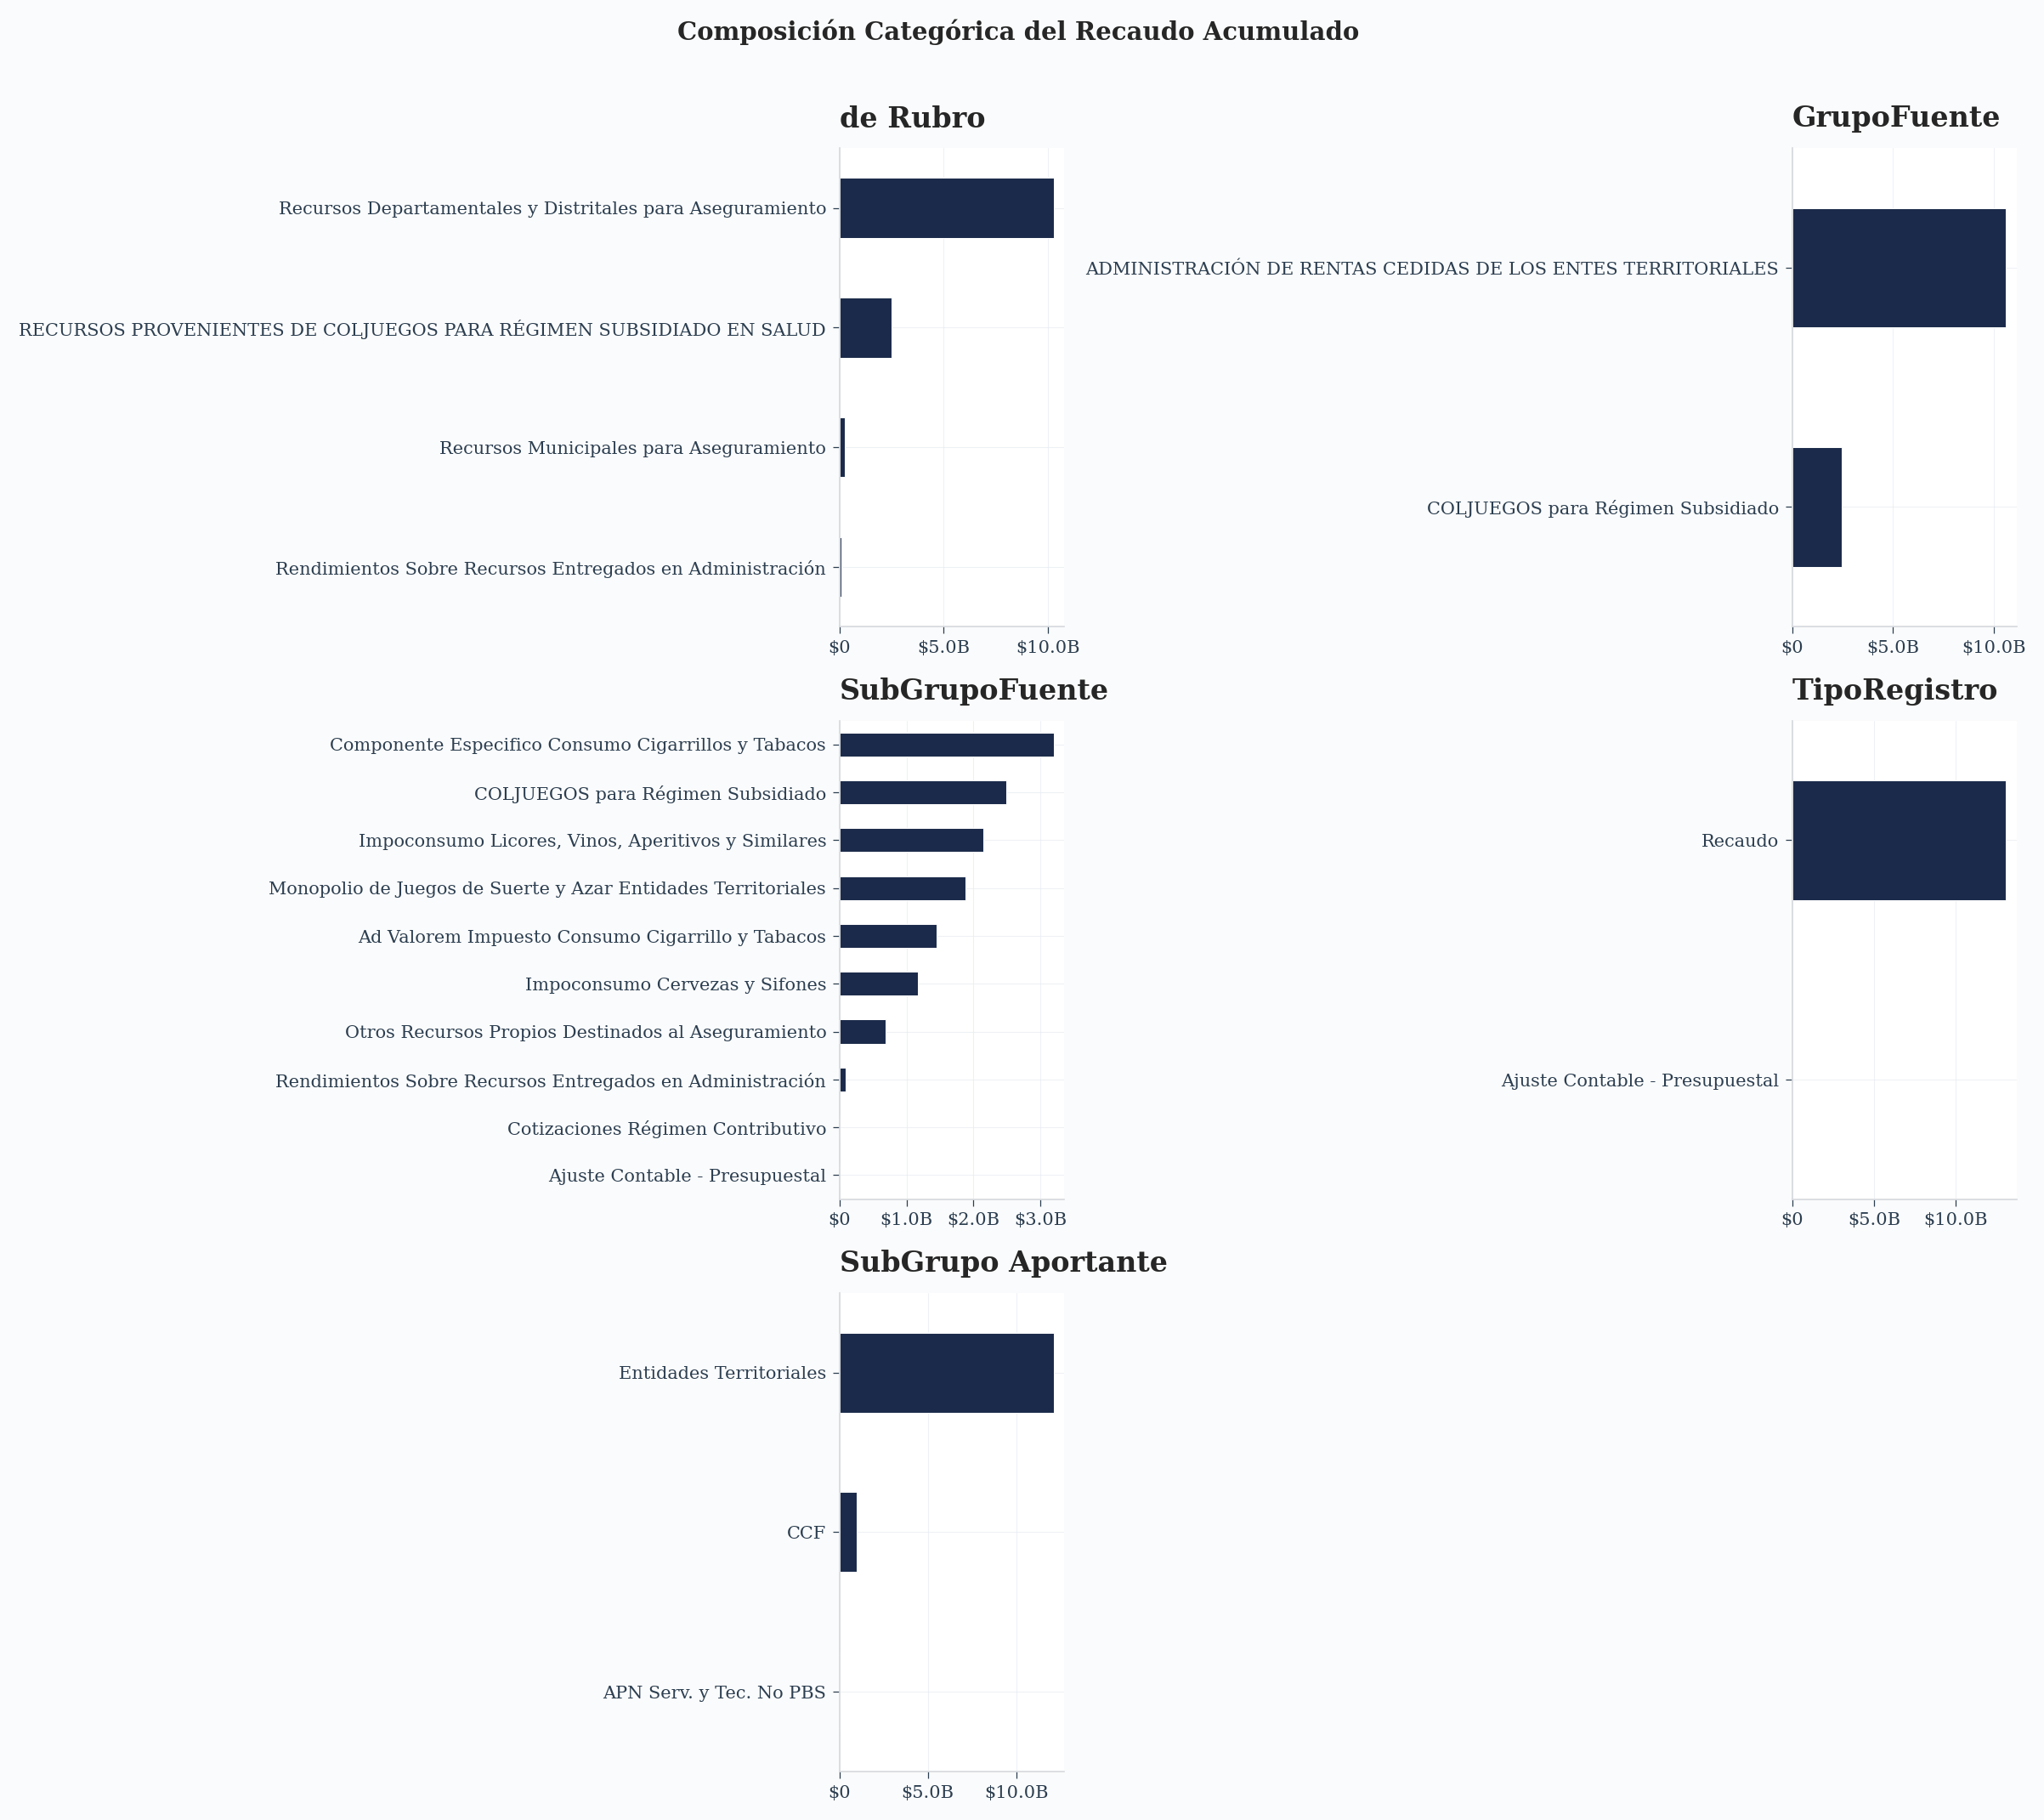


══════════════════════════════════════════════════════════════════════
PARTICIPACIÓN POR SUBGRUPO FUENTE (% del recaudo neto)
══════════════════════════════════════════════════════════════════════
  Componente Especifico Consumo Cigarrillos y Tabacos           24.40%  ($3,196,398,340,488)
  COLJUEGOS para Régimen Subsidiado                             18.95%  ($2,483,338,234,828)
  Impoconsumo Licores, Vinos, Aperitivos y Similares            16.34%  ($2,140,971,314,675)
  Monopolio de Juegos de Suerte y Azar Entidades Territoriales  14.38%  ($1,884,514,618,073)
  Ad Valorem Impuesto Consumo Cigarrillo y Tabacos              11.03%  ($1,444,857,890,309)
  Impoconsumo Cervezas y Sifones                                 8.93%  ($1,170,029,625,646)
  Otros Recursos Propios Destinados al Aseguramiento             5.29%  ($692,463,438,440)
  Rendimientos Sobre Recursos Entregados en Administración       0.66%  ($ 86,639,183,099)
  Cotizaciones Régimen Contributivo                           

In [4]:
# ── 1.3 Exploración categórica ────────────────────────────────────
cat_cols = ['Nombre de Rubro', 'NombreGrupoFuente', 'NombreSubGrupoFuente',
            'TipoRegistro', 'Nombre_SubGrupo_Aportante']

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flat

for i, col in enumerate(cat_cols):
    ax = axes[i]
    # Calcular participación por categoría
    resumen = (df.groupby(col)[COL_VALOR].sum()
               .sort_values(ascending=True))
    colores = [C_PRIMARY if v >= 0 else C_NEGATIVE for v in resumen.values]
    resumen.plot.barh(ax=ax, color=colores, edgecolor='white', linewidth=0.5)
    
    if _VIZ_THEME_LOADED:
        titulo_profesional(ax, col.replace('Nombre', '').replace('_', ' ').strip())
        formato_pesos_eje(ax, eje='x')
    else:
        ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel('')

# Ocultar subplot sobrante
axes[5].axis('off')

fig.suptitle('Composición Categórica del Recaudo Acumulado',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
if _VIZ_THEME_LOADED:
    guardar_figura(fig, '01_composicion_categorica', OUTPUTS_FIGURES)
plt.show()

# Tabla resumen de participación
print("\n" + "═" * 70)
print("PARTICIPACIÓN POR SUBGRUPO FUENTE (% del recaudo neto)")
print("═" * 70)
total = df[COL_VALOR].sum()
part = (df.groupby('NombreSubGrupoFuente')[COL_VALOR].sum()
        .sort_values(ascending=False))
for nombre, valor in part.items():
    pct = valor / total * 100
    print(f"  {nombre:<60} {pct:6.2f}%  (${valor:>15,.0f})")


---
## Fase II — Agregación Mensual y Visualización Temporal
### 2.1  Remuestreo mensual y estadísticas descriptivas

Se agrega el recaudo transaccional a frecuencia mensual (`MS` = *Month Start*)
mediante sumatoria, generando la **serie objetivo** para todos los modelos
predictivos posteriores. Se calculan estadísticos de localización y dispersión.


In [5]:
# ── 2.1 Agregación mensual ────────────────────────────────────────
serie = df[COL_VALOR].resample('MS').sum()
df_mensual = serie.to_frame(name='Recaudo_Total')
df_mensual['Año'] = df_mensual.index.year
df_mensual['Mes'] = df_mensual.index.month
df_mensual['Mes_Nombre'] = df_mensual.index.strftime('%b')

n_meses = len(df_mensual)
print(f"Serie mensual generada: {n_meses} observaciones")
print(f"Periodo: {df_mensual.index.min():%Y-%m} → {df_mensual.index.max():%Y-%m}\n")

# Estadísticas descriptivas
desc = df_mensual['Recaudo_Total'].describe()
print("═" * 50)
print("ESTADÍSTICAS DESCRIPTIVAS — Recaudo Mensual")
print("═" * 50)
for idx, val in desc.items():
    print(f"  {idx:<12} ${val:>18,.0f}")

cv = desc['std'] / desc['mean'] * 100
print(f"  {'CV (%):':<12} {cv:>18.2f}%")

# Adicionar IQR y rango
iqr = desc['75%'] - desc['25%']
rango = desc['max'] - desc['min']
print(f"  {'IQR:':<12} ${iqr:>18,.0f}")
print(f"  {'Rango:':<12} ${rango:>18,.0f}")

print(f"\n📋 Primeros 6 meses:")
print(df_mensual[['Recaudo_Total']].head(6).to_string())
print(f"\n📋 Últimos 6 meses:")
print(df_mensual[['Recaudo_Total']].tail(6).to_string())


Serie mensual generada: 51 observaciones
Periodo: 2021-10 → 2025-12

══════════════════════════════════════════════════
ESTADÍSTICAS DESCRIPTIVAS — Recaudo Mensual
══════════════════════════════════════════════════
  count        $                51
  mean         $   256,904,524,541
  std          $    69,890,991,881
  min          $   161,694,067,166
  25%          $   211,481,307,953
  50%          $   233,829,383,673
  75%          $   293,171,906,460
  max          $   471,616,429,730
  CV (%):                   27.21%
  IQR:         $    81,690,598,507
  Rango:       $   309,922,362,564

📋 Primeros 6 meses:
              Recaudo_Total
FechaRecaudo               
2021-10-01     2.246001e+11
2021-11-01     2.223505e+11
2021-12-01     2.145339e+11
2022-01-01     3.042595e+11
2022-02-01     1.799894e+11
2022-03-01     2.766571e+11

📋 Últimos 6 meses:
              Recaudo_Total
FechaRecaudo               
2025-07-01     4.204315e+11
2025-08-01     2.693286e+11
2025-09-01     2.688362

### 2.2  Serie de tiempo — Evolución histórica

Visualización profesional de la serie mensual con:
- **Media móvil** de 6 meses para suavizar la variabilidad de corto plazo.
- **Marcadores de picos** en enero y julio (meses de mayor recaudo históricamente).
- **Línea de media** como referencia de nivel central.
- **Zona train/test** para visualizar el corte de validación.


  📊 Figura guardada: 01_serie_tiempo_recaudo.png


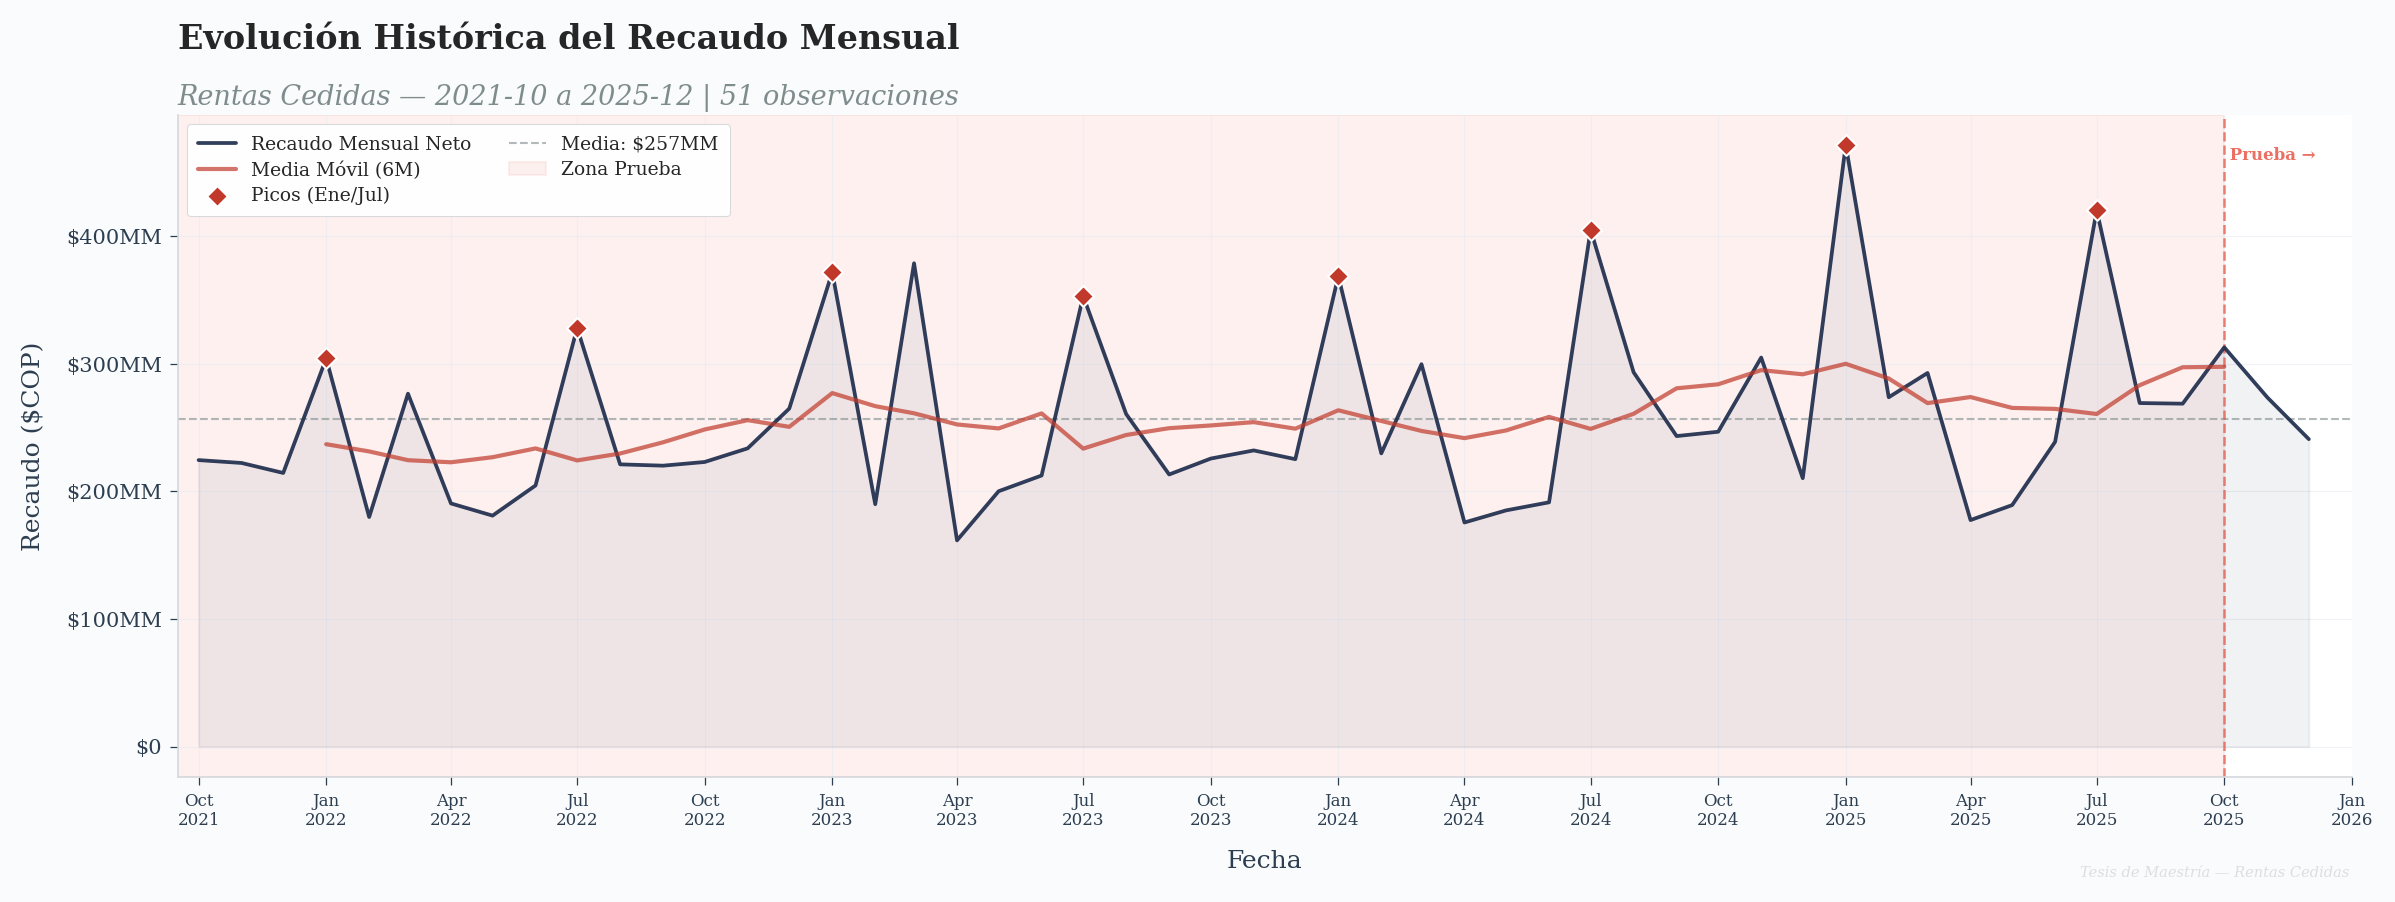

In [6]:
# ── 2.2 Gráfica de serie de tiempo ────────────────────────────────
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE if _VIZ_THEME_LOADED else (16, 6))

# Rango del eje X: período real de los datos con margen
x_inicio = df_mensual.index[0] - pd.DateOffset(days=15)
x_fin    = df_mensual.index[-1] + pd.DateOffset(months=1)

if _VIZ_THEME_LOADED:
    grafica_serie_tiempo(ax, df_mensual.index, df_mensual['Recaudo_Total'],
                         label='Recaudo Mensual Neto', color=C_PRIMARY,
                         mostrar_ma=True, ma_window=6, mostrar_picos=True,
                         meses_pico=MESES_PICO)
    linea_media(ax, df_mensual['Recaudo_Total'].mean())
    # Fijar xlim ANTES de zona_train_test para evitar expansión al epoch
    ax.set_xlim(x_inicio, x_fin)
    zona_train_test(ax, pd.Timestamp(TRAIN_END), pd.Timestamp(TEST_START))
    titulo_profesional(ax,
        'Evolución Histórica del Recaudo Mensual',
        f'Rentas Cedidas — {FECHA_INICIO[:7]} a {FECHA_FIN[:7]} | {n_meses} observaciones')
    leyenda_profesional(ax, loc='upper left', ncol=2)
    marca_agua(fig)
else:
    ax.plot(df_mensual.index, df_mensual['Recaudo_Total'], color='b',
            marker='o', linewidth=1.5, label='Recaudo Mensual')
    ma6 = df_mensual['Recaudo_Total'].rolling(6, center=True).mean()
    ax.plot(df_mensual.index, ma6, color='r', linewidth=2, label='MA(6)')
    ax.axhline(df_mensual['Recaudo_Total'].mean(), color='gray', ls='--', lw=1)
    ax.set_title('Evolución Histórica del Recaudo Mensual', fontsize=14, fontweight='bold')
    ax.legend()

# Rango y formato de fechas en eje X
ax.set_xlim(x_inicio, x_fin)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
plt.setp(ax.xaxis.get_majorticklabels(), fontsize=8, ha='center')

ax.set_xlabel('Fecha')
ax.set_ylabel('Recaudo ($COP)')
plt.tight_layout()
if _VIZ_THEME_LOADED:
    guardar_figura(fig, '01_serie_tiempo_recaudo', OUTPUTS_FIGURES)
plt.show()

### 2.3a  Distribución mensual (Boxplot)

**Boxplot mensual** — distribución del recaudo por mes del año, revelando
la variabilidad intra-mensual y los meses de mayor concentración.
Los meses marcados como **pico** (enero y julio) se resaltan en color diferenciado.

  📊 Figura guardada: 01_estacionalidad_boxplot.png


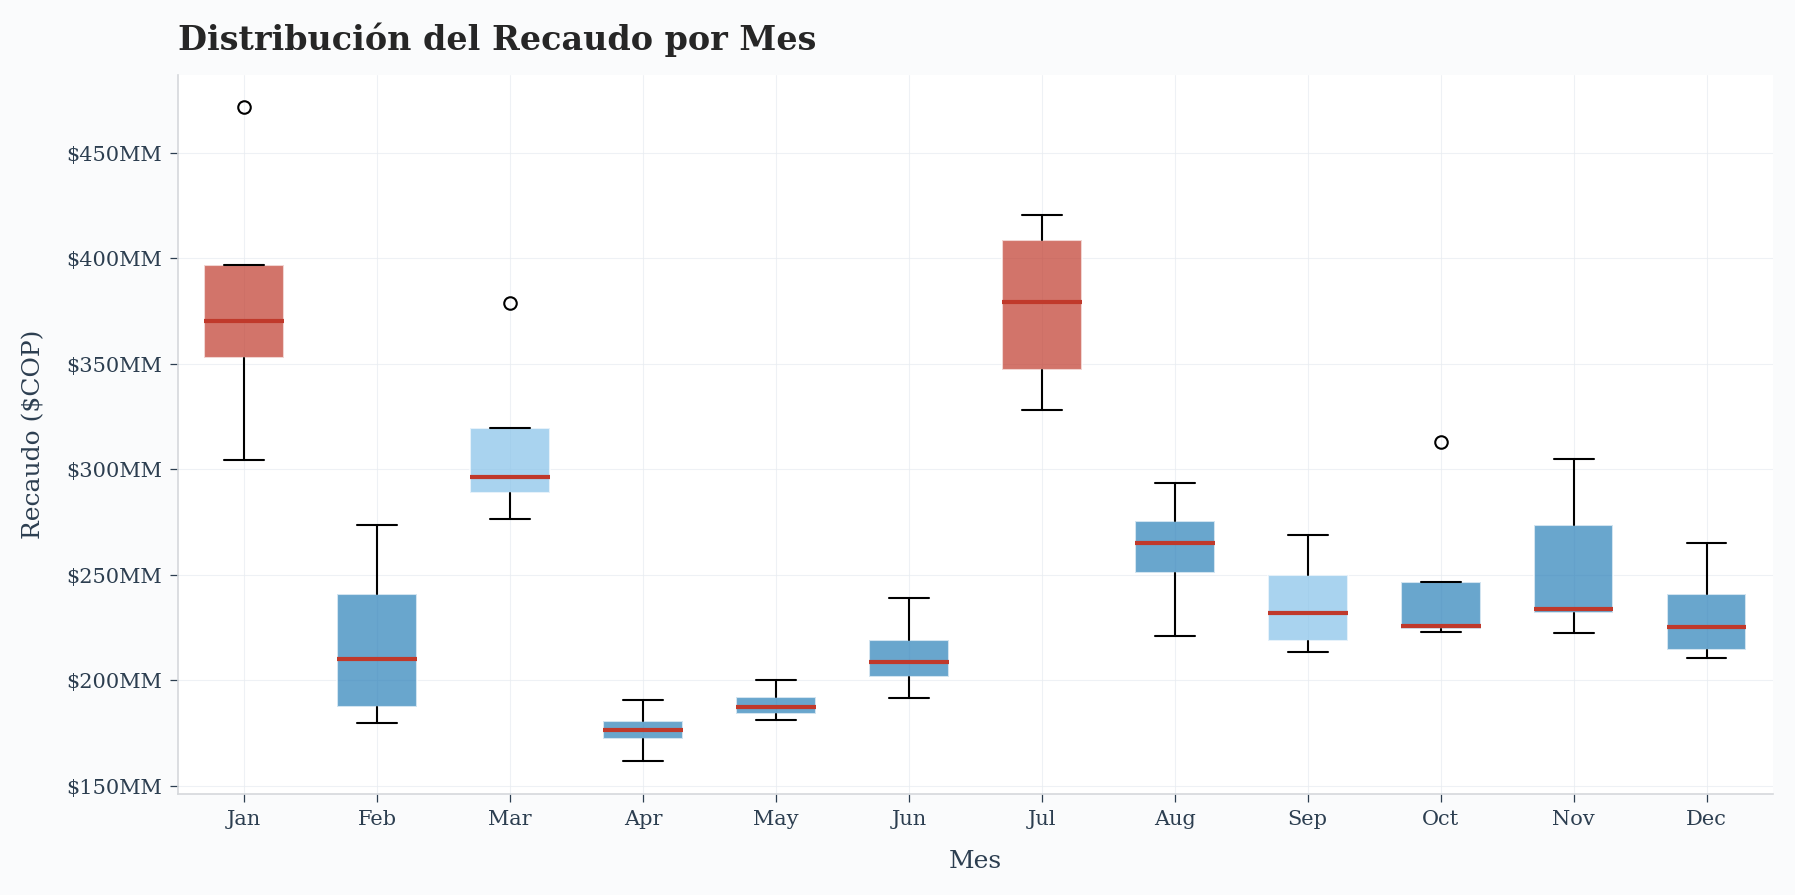


═════════════════════════════════════════════
RECAUDO PROMEDIO POR MES
═════════════════════════════════════════════
   Jan:  $379,164,633,038 ★ PICO
   Jul:  $376,724,849,332 ★ PICO
   Mar:  $312,069,016,335
   Aug:  $261,181,210,181
   Nov:  $253,435,736,723
   Oct:  $246,678,124,449
   Sep:  $236,459,951,442
   Dec:  $231,266,698,416
   Feb:  $218,438,462,814
   Jun:  $211,921,559,226
   May:  $188,943,840,485
   Apr:  $176,403,465,561


In [7]:
# ── 2.3a Estacionalidad: Boxplot mensual ──────────────────────────
fig, ax = plt.subplots(figsize=FIGSIZE_STANDARD if _VIZ_THEME_LOADED else (12, 6))

meses_labels = [calendar.month_abbr[m] for m in range(1, 13)]
box_data = [df_mensual[df_mensual['Mes'] == m]['Recaudo_Total'].values
            for m in range(1, 13)]
bp = ax.boxplot(box_data, patch_artist=True, labels=meses_labels,
                widths=0.6, medianprops={'color': C_SECONDARY, 'linewidth': 2})
for i, patch in enumerate(bp['boxes']):
    mes = i + 1
    color = C_BAR_PEAK if mes in MESES_PICO else (C_BAR_VALLEY if mes in [3, 9] else C_BAR_NORMAL)
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_edgecolor('white')

if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Distribución del Recaudo por Mes')
    formato_pesos_eje(ax)
else:
    ax.set_title('Distribución por Mes', fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Recaudo ($COP)')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    guardar_figura(fig, '01_estacionalidad_boxplot', OUTPUTS_FIGURES)
plt.show()

# Resumen numérico de estacionalidad
print("\n═════════════════════════════════════════════")
print("RECAUDO PROMEDIO POR MES")
print("═════════════════════════════════════════════")
prom_mes = df_mensual.groupby('Mes')['Recaudo_Total'].mean().sort_values(ascending=False)
for m, val in prom_mes.items():
    marca = " ★ PICO" if m in MESES_PICO else ""
    print(f"  {calendar.month_abbr[m]:>4}:  ${val:>15,.0f}{marca}")

### 2.3b  Mapa de Calor Año × Mes

Mapa de calor que cruza **año** y **mes** para visualizar la concentración
del recaudo a lo largo del tiempo. Permite detectar *level shifts*
interanuales y confirmar los meses de mayor contribución.

  📊 Figura guardada: 01_estacionalidad_heatmap.png


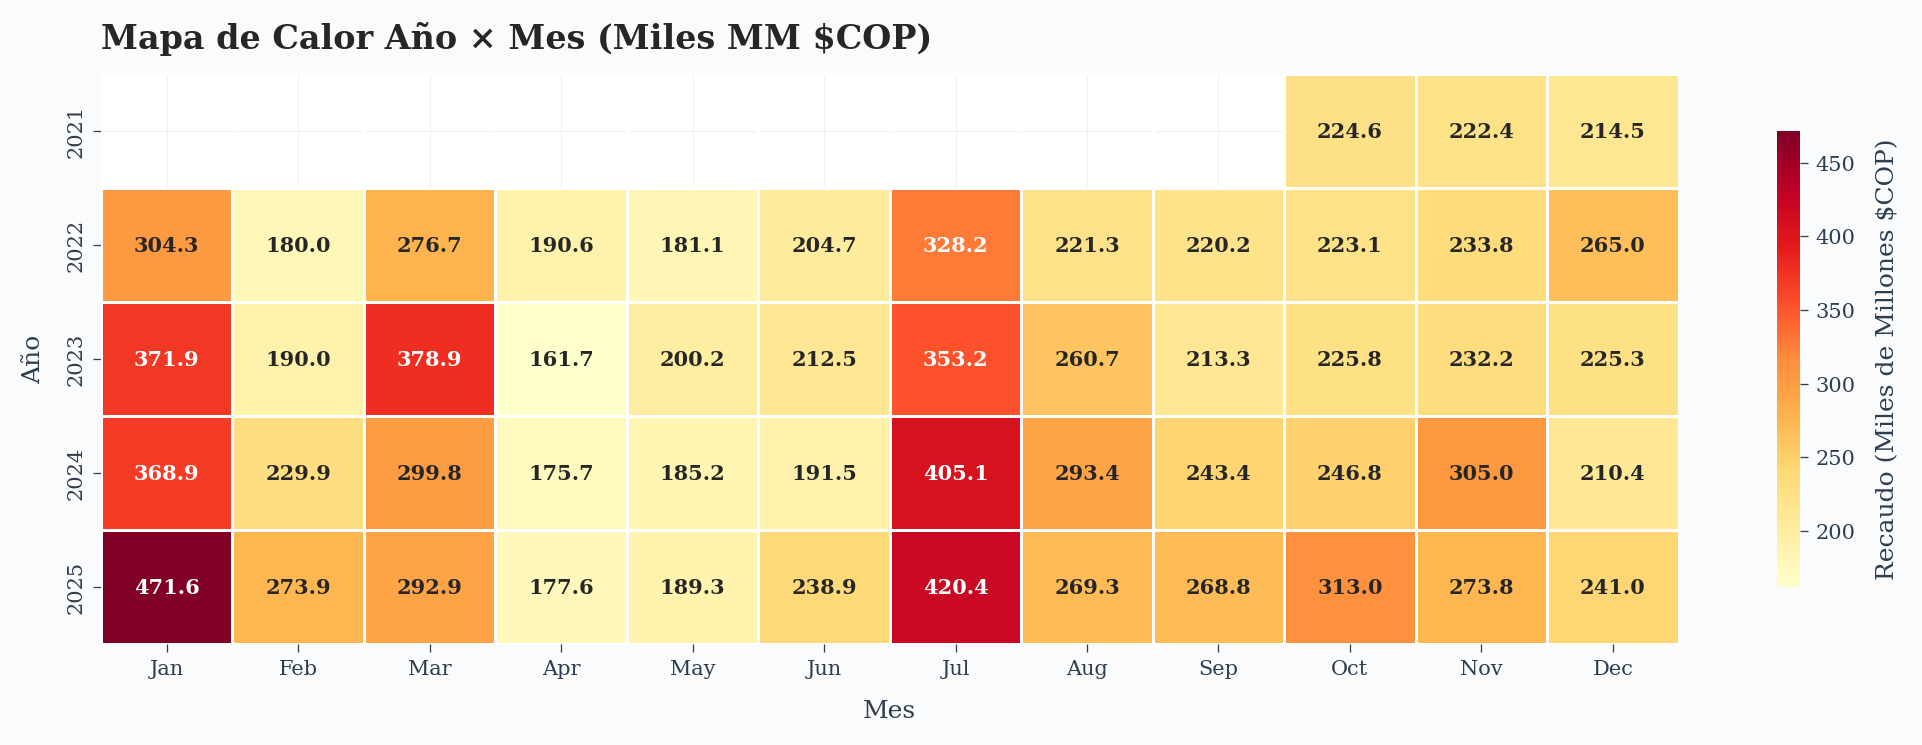

In [9]:
# ── 2.3b Estacionalidad: Heatmap año × mes ───────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

pivot = df_mensual.pivot_table(values='Recaudo_Total', index='Año',
                                columns='Mes', aggfunc='sum')
pivot.columns = [calendar.month_abbr[m] for m in pivot.columns]

# Escalar a miles de millones para anotaciones legibles
pivot_display = pivot / 1e9
fmt_label = 'Recaudo (Miles de Millones $COP)'

sns.heatmap(pivot_display, annot=True, fmt=',.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, annot_kws={'size': 10, 'weight': 'bold'},
            cbar_kws={'label': fmt_label, 'shrink': 0.8})

if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Mapa de Calor Año × Mes (Miles MM $COP)')
else:
    ax.set_title('Mapa de Calor Año × Mes (Miles MM $COP)', fontweight='bold')
ax.set_ylabel('Año')
ax.set_xlabel('Mes')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    guardar_figura(fig, '01_estacionalidad_heatmap', OUTPUTS_FIGURES)
plt.show()

---
## Fase III — Descomposición, Estacionariedad y Autocorrelación
### 3.1  Descomposición estacional clásica

Se aplica el método de **descomposición clásica** (Cleveland *et al.*, 1990) para
separar la serie $Y_t$ en sus componentes fundamentales:

$$Y_t = T_t + S_t + R_t \quad \text{(modelo aditivo)}$$

donde $T_t$ es la tendencia-ciclo, $S_t$ la componente estacional y $R_t$ el residuo.
Se evalúan tanto el modelo **aditivo** como el **multiplicativo** para determinar
cuál captura mejor la estructura de la serie.


  📊 Figura guardada: 01_descomposicion_estacional.png


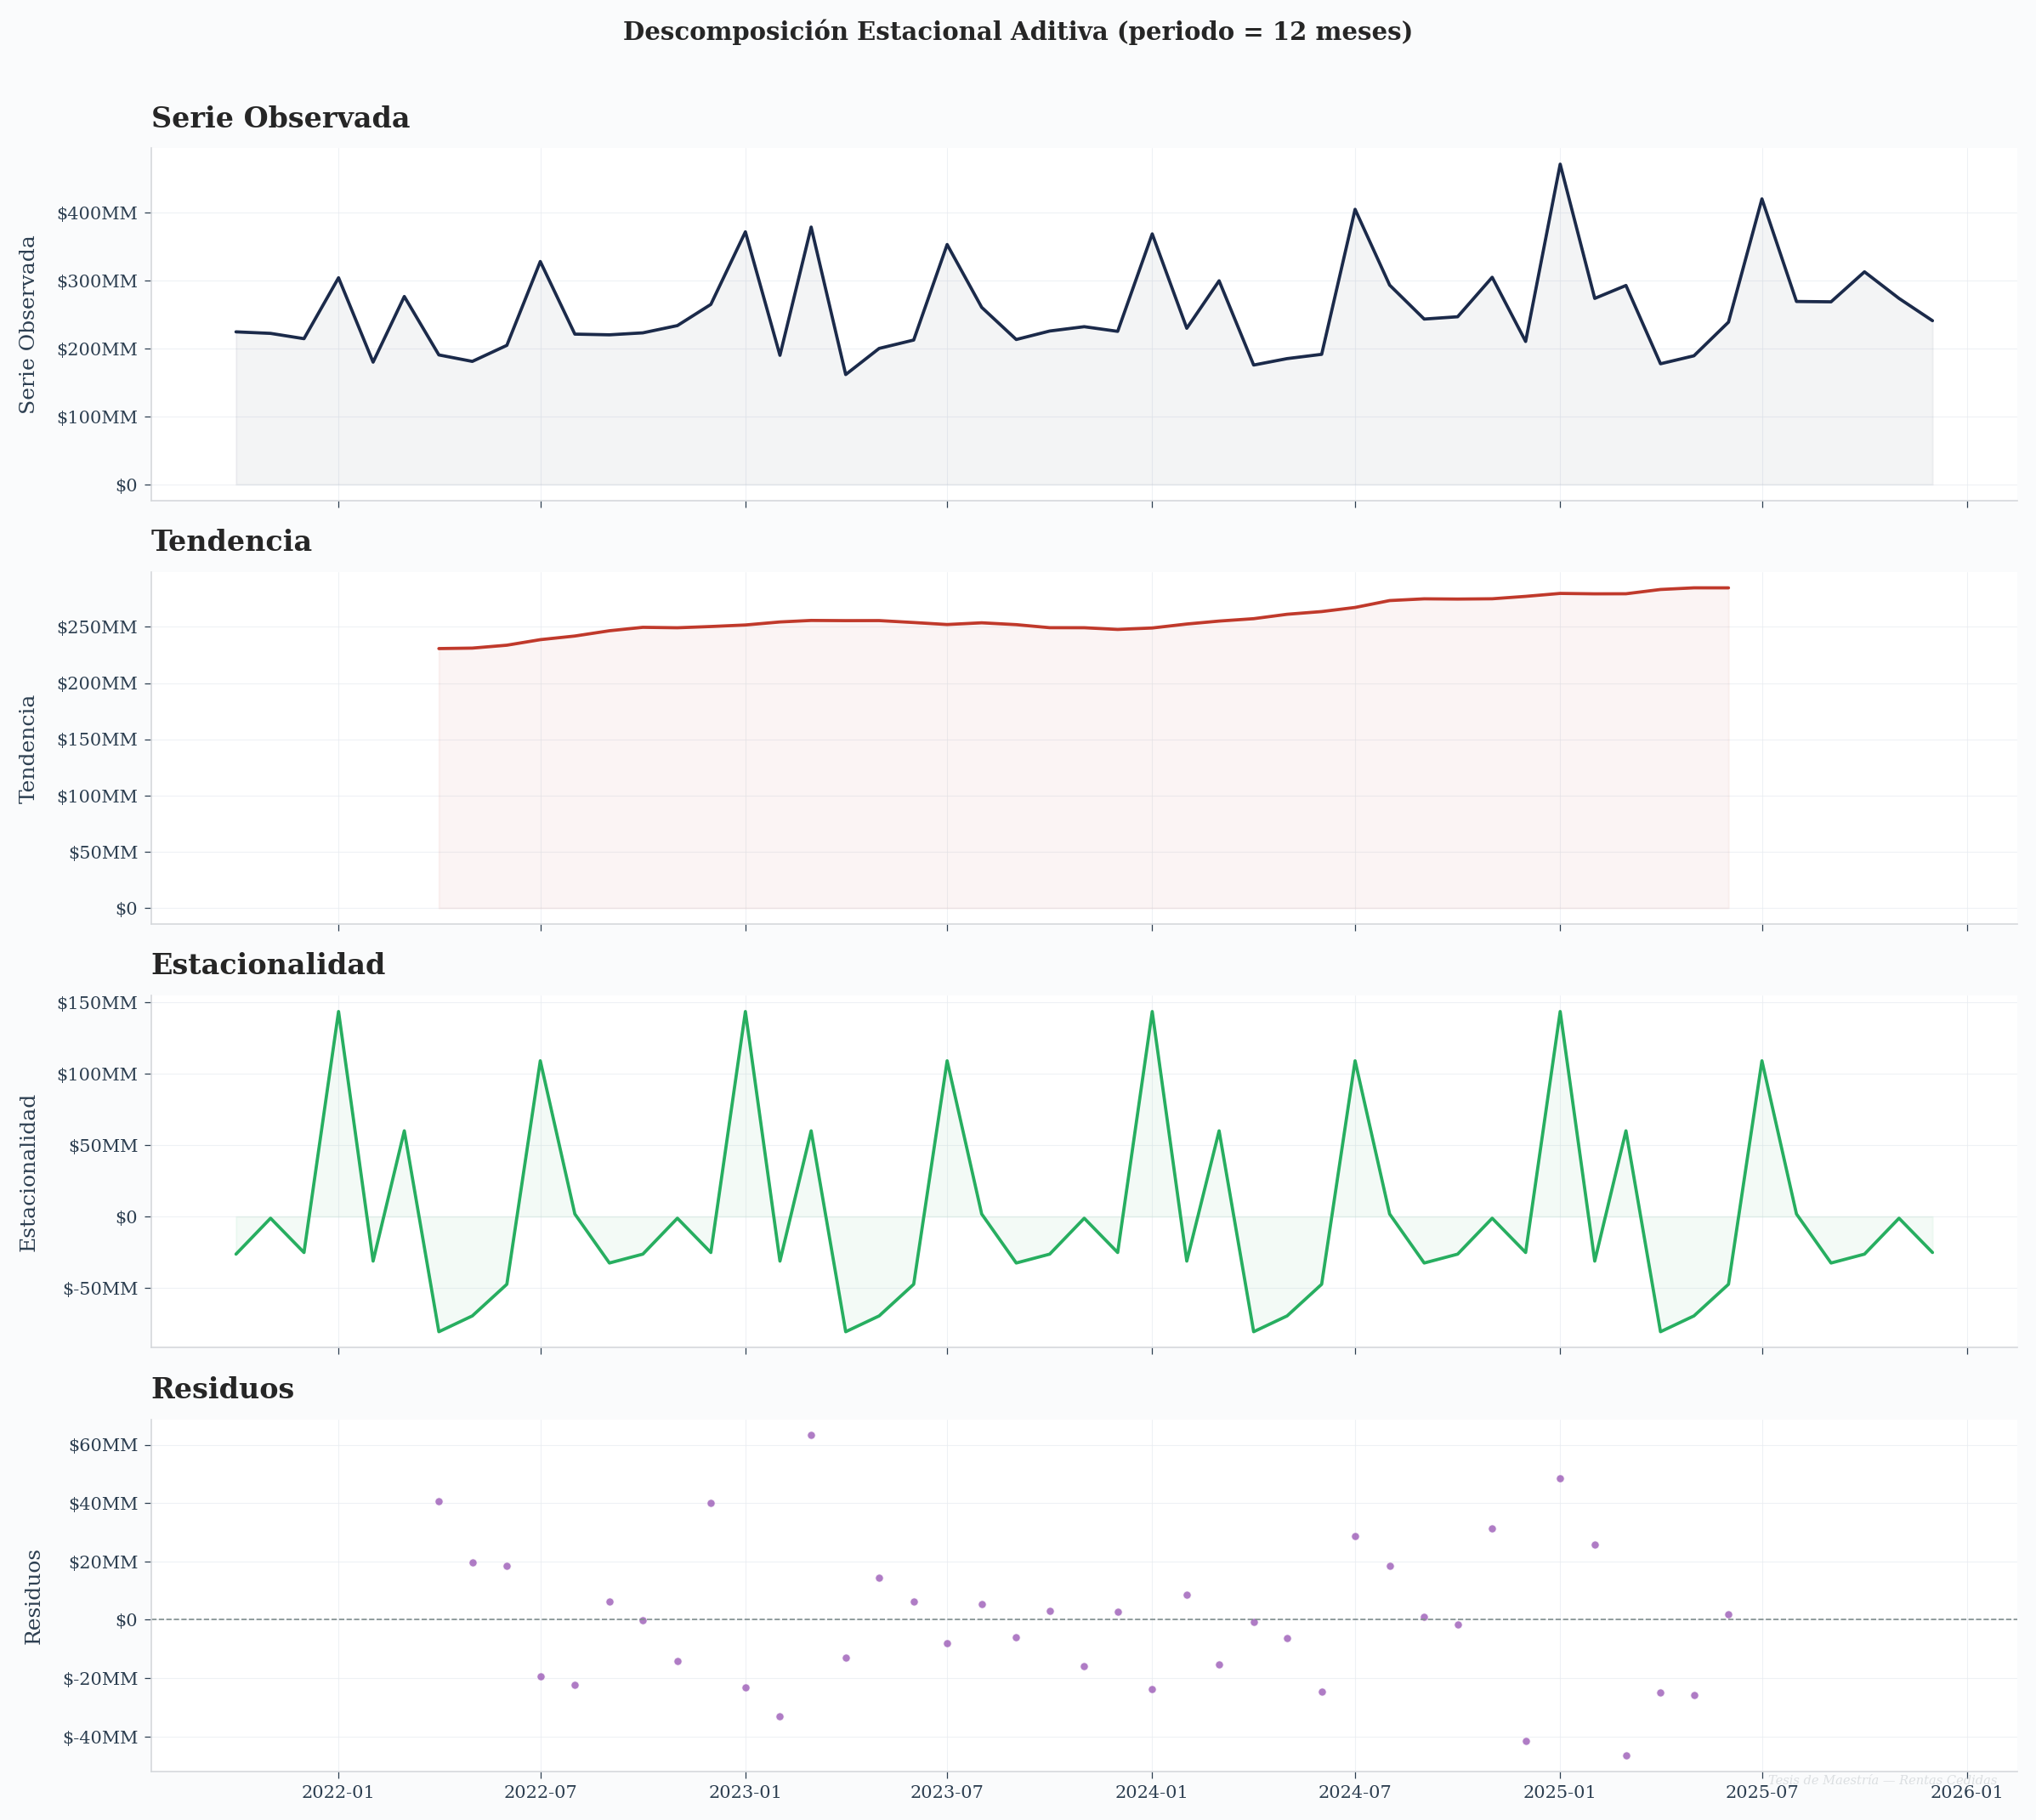


══════════════════════════════════════════════════
FUERZA DE LOS COMPONENTES (Hyndman & Athanasopoulos)
══════════════════════════════════════════════════
  Fuerza de Estacionalidad (F_s): 0.8804  → FUERTE
  Fuerza de Tendencia     (F_t):  0.1825  → DÉBIL

  Interpretación: F > 0.64 indica componente significativo (Hyndman, 2021)


In [14]:
# ── 3.1 Descomposición estacional ─────────────────────────────────
serie_clean = df_mensual['Recaudo_Total'].ffill()

# Descomposición aditiva
decomp_add = seasonal_decompose(serie_clean, model='additive', period=ESTACIONALIDAD)

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

componentes = [
    (decomp_add.observed, 'Serie Observada', C_PRIMARY),
    (decomp_add.trend,    'Tendencia',       C_SECONDARY),
    (decomp_add.seasonal, 'Estacionalidad',  C_QUATERNARY),
    (decomp_add.resid,    'Residuos',        C_SENARY),
]

for ax, (data, titulo, color) in zip(axes, componentes):
    if titulo == 'Residuos':
        ax.scatter(data.index, data, color=color, s=20, alpha=0.7, edgecolors='white', linewidth=0.5)
        ax.axhline(0, color=C_TEXT_LIGHT, ls='--', lw=0.8)
    else:
        ax.plot(data.index, data, color=color, linewidth=1.8)
        ax.fill_between(data.index, 0, data, alpha=0.05, color=color)
    
    if _VIZ_THEME_LOADED:
        titulo_profesional(ax, titulo)
        formato_pesos_eje(ax)
    else:
        ax.set_title(titulo, fontweight='bold')
    ax.set_ylabel(titulo)

fig.suptitle('Descomposición Estacional Aditiva (periodo = 12 meses)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '01_descomposicion_estacional', OUTPUTS_FIGURES)
plt.show()

# Fuerza de la estacionalidad (Hyndman & Athanasopoulos, 2021)
var_resid = np.nanvar(decomp_add.resid)
var_resid_plus_season = np.nanvar(decomp_add.resid + decomp_add.seasonal)
F_s = max(0, 1 - var_resid / var_resid_plus_season)

var_trend_plus_resid = np.nanvar(decomp_add.trend.dropna() + decomp_add.resid.dropna()[:len(decomp_add.trend.dropna())])
var_resid_trend = np.nanvar(decomp_add.resid.dropna()[:len(decomp_add.trend.dropna())])
F_t = max(0, 1 - var_resid_trend / var_trend_plus_resid)

print(f"\n{'═' * 50}")
print(f"FUERZA DE LOS COMPONENTES (Hyndman & Athanasopoulos)")
print(f"{'═' * 50}")
print(f"  Fuerza de Estacionalidad (F_s): {F_s:.4f}  {'→ FUERTE' if F_s > 0.64 else '→ DÉBIL'}")
print(f"  Fuerza de Tendencia     (F_t):  {F_t:.4f}  {'→ FUERTE' if F_t > 0.64 else '→ DÉBIL'}")
print(f"\n  Interpretación: F > 0.64 indica componente significativo (Hyndman, 2021)")


### 3.2  Pruebas de estacionariedad

Se aplican dos pruebas complementarias con hipótesis opuestas:

| Prueba | H₀ | H₁ | Decisión si p < α |
|--------|----|----|-------------------|
| **ADF** (Dickey-Fuller Aumentada) | Raíz unitaria (no estacionaria) | Estacionaria | Rechazar H₀ → estacionaria |
| **KPSS** (Kwiatkowski–Phillips–Schmidt–Shin) | Estacionaria | Raíz unitaria | Rechazar H₀ → no estacionaria |

La combinación ADF + KPSS permite un diagnóstico robusto:
- ADF rechaza + KPSS no rechaza → **estacionaria** ✅
- ADF no rechaza + KPSS rechaza → **no estacionaria** ✗
- Ambas rechazan → **estacionaria con tendencia** (diferenciación necesaria)



════════════════════════════════════════════════════════════
DIAGNÓSTICO DE ESTACIONARIEDAD: Recaudo Mensual
════════════════════════════════════════════════════════════

► Prueba ADF (Dickey-Fuller Aumentada):
  Estadístico:      -0.2642
  p-valor:          0.930422
  Lags usados:      11
  Observaciones:    39
  Valor crítico 1%: -3.6104
  Valor crítico 5%: -2.9391
  Valor crítico 10%: -2.6081
  → Decisión (α=0.05): NO ESTACIONARIA

► Prueba KPSS (Kwiatkowski-Phillips-Schmidt-Shin):
  Estadístico:      0.3162
  p-valor:          0.1000
  Lags usados:      0
  Valor crítico 10%: 0.3470
  Valor crítico 5%: 0.4630
  Valor crítico 2.5%: 0.5740
  Valor crítico 1%: 0.7390
  → Decisión (α=0.05): ESTACIONARIA

──────────────────────────────────────────────────
  VEREDICTO: 🔍 INCONCLUSO (ninguna rechaza H₀ — revisar manualmente)


C:\Users\efren\AppData\Local\Temp\ipykernel_24980\564933314.py:21: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(serie, regression='c', nlags='auto')


  📊 Figura guardada: 01_estacionariedad_rolling.png


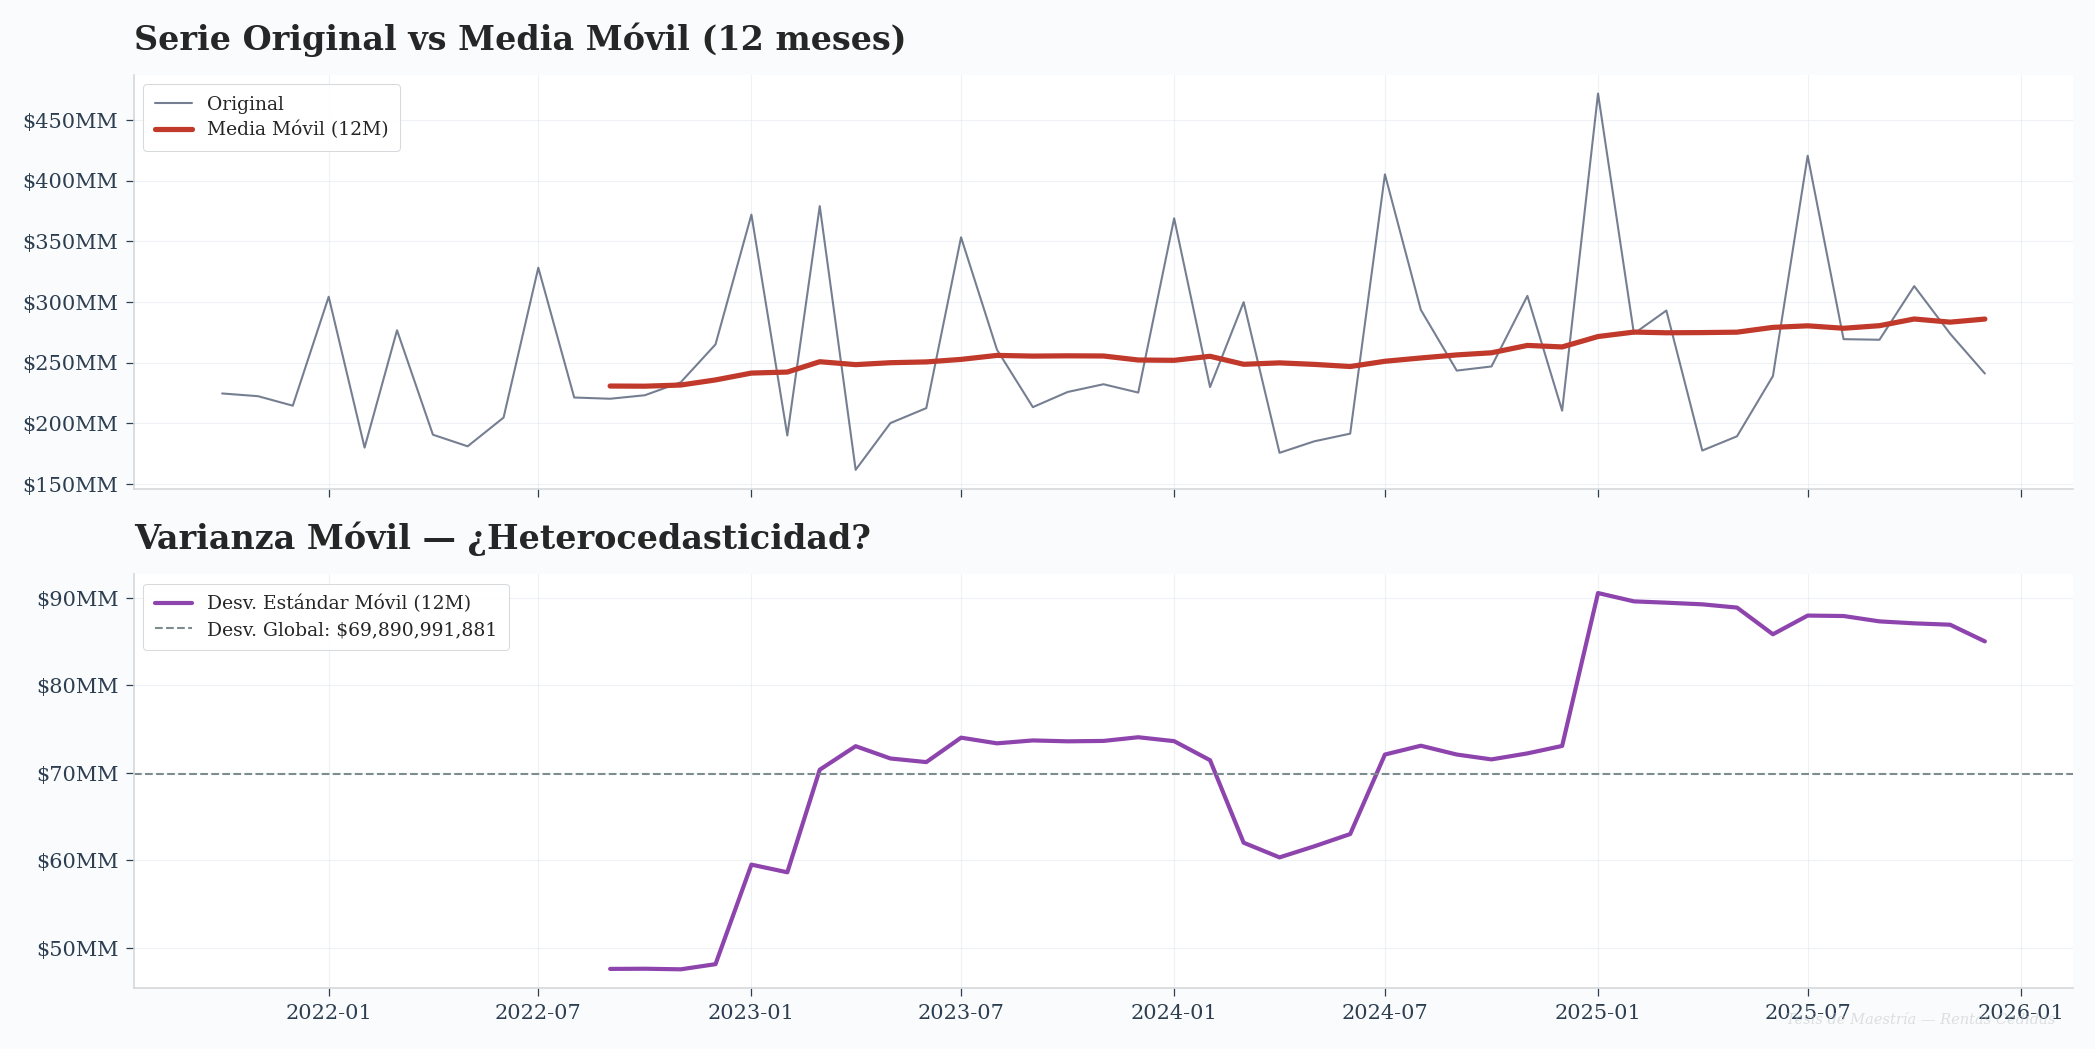

In [9]:
# ── 3.2 Pruebas de estacionariedad ────────────────────────────────
def diagnostico_estacionariedad(serie, nombre='Serie'):
    # Ejecuta ADF + KPSS y genera reporte consolidado.
    print(f"\n{'═' * 60}")
    print(f"DIAGNÓSTICO DE ESTACIONARIEDAD: {nombre}")
    print(f"{'═' * 60}")
    
    # ADF
    adf_stat, adf_p, adf_lags, adf_nobs, adf_crit, _ = adfuller(serie, autolag='AIC')
    print(f"\n► Prueba ADF (Dickey-Fuller Aumentada):")
    print(f"  Estadístico:      {adf_stat:.4f}")
    print(f"  p-valor:          {adf_p:.6f}")
    print(f"  Lags usados:      {adf_lags}")
    print(f"  Observaciones:    {adf_nobs}")
    for k, v in adf_crit.items():
        print(f"  Valor crítico {k}: {v:.4f}")
    adf_decision = "ESTACIONARIA" if adf_p <= 0.05 else "NO ESTACIONARIA"
    print(f"  → Decisión (α=0.05): {adf_decision}")
    
    # KPSS
    kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(serie, regression='c', nlags='auto')
    print(f"\n► Prueba KPSS (Kwiatkowski-Phillips-Schmidt-Shin):")
    print(f"  Estadístico:      {kpss_stat:.4f}")
    print(f"  p-valor:          {kpss_p:.4f}")
    print(f"  Lags usados:      {kpss_lags}")
    for k, v in kpss_crit.items():
        print(f"  Valor crítico {k}: {v:.4f}")
    kpss_decision = "ESTACIONARIA" if kpss_p > 0.05 else "NO ESTACIONARIA"
    print(f"  → Decisión (α=0.05): {kpss_decision}")
    
    # Diagnóstico combinado
    print(f"\n{'─' * 50}")
    if adf_p <= 0.05 and kpss_p > 0.05:
        veredicto = "✅ ESTACIONARIA (ADF rechaza H₀ + KPSS no rechaza H₀)"
    elif adf_p > 0.05 and kpss_p <= 0.05:
        veredicto = "❌ NO ESTACIONARIA (ADF no rechaza H₀ + KPSS rechaza H₀)"
    elif adf_p <= 0.05 and kpss_p <= 0.05:
        veredicto = "⚠️ ESTACIONARIA con TENDENCIA (ambas rechazan H₀ — requiere diferenciación)"
    else:
        veredicto = "🔍 INCONCLUSO (ninguna rechaza H₀ — revisar manualmente)"
    print(f"  VEREDICTO: {veredicto}")
    
    return {'adf_p': adf_p, 'kpss_p': kpss_p, 'adf_stat': adf_stat, 'kpss_stat': kpss_stat}

# Ejecutar sobre la serie original
resultados_est = diagnostico_estacionariedad(serie_clean, 'Recaudo Mensual')

# Visualización de media/varianza móvil
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=FIGSIZE_FULL if _VIZ_THEME_LOADED else (14, 8),
                                sharex=True)

rolmean = serie_clean.rolling(window=12).mean()
rolstd = serie_clean.rolling(window=12).std()

# Panel superior: serie + media móvil
ax1.plot(serie_clean.index, serie_clean, color=C_PRIMARY, alpha=0.6, linewidth=1, label='Original')
ax1.plot(rolmean.index, rolmean, color=C_SECONDARY, linewidth=2.5, label='Media Móvil (12M)')
if _VIZ_THEME_LOADED:
    titulo_profesional(ax1, 'Serie Original vs Media Móvil (12 meses)')
    formato_pesos_eje(ax1)
    leyenda_profesional(ax1, loc='upper left')
else:
    ax1.set_title('Serie Original vs Media Móvil', fontweight='bold')
    ax1.legend()

# Panel inferior: desviación estándar móvil
ax2.plot(rolstd.index, rolstd, color=C_SENARY, linewidth=2, label='Desv. Estándar Móvil (12M)')
ax2.axhline(serie_clean.std(), color=C_TEXT_LIGHT, ls='--', lw=1, label=f'Desv. Global: ${serie_clean.std():,.0f}')
if _VIZ_THEME_LOADED:
    titulo_profesional(ax2, 'Varianza Móvil — ¿Heterocedasticidad?')
    formato_pesos_eje(ax2)
    leyenda_profesional(ax2, loc='upper left')
else:
    ax2.set_title('Desviación Estándar Móvil', fontweight='bold')
    ax2.legend()

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '01_estacionariedad_rolling', OUTPUTS_FIGURES)
plt.show()


### 3.3  Funciones de autocorrelación (ACF / PACF)

Los correlogramas permiten identificar la **estructura de dependencia temporal** 
de la serie, fundamental para parametrizar modelos ARIMA/SARIMA:

- **ACF** → patrones de decaimiento indican el orden MA ($q$) y la estacionalidad.
  Picos significativos en lags múltiplos de 12 confirman estacionalidad anual.
- **PACF** → cortes abruptos indican el orden AR ($p$).
  Picos en lag 12 sugieren componente AR estacional ($P$).


  📊 Figura guardada: 01_acf_pacf.png


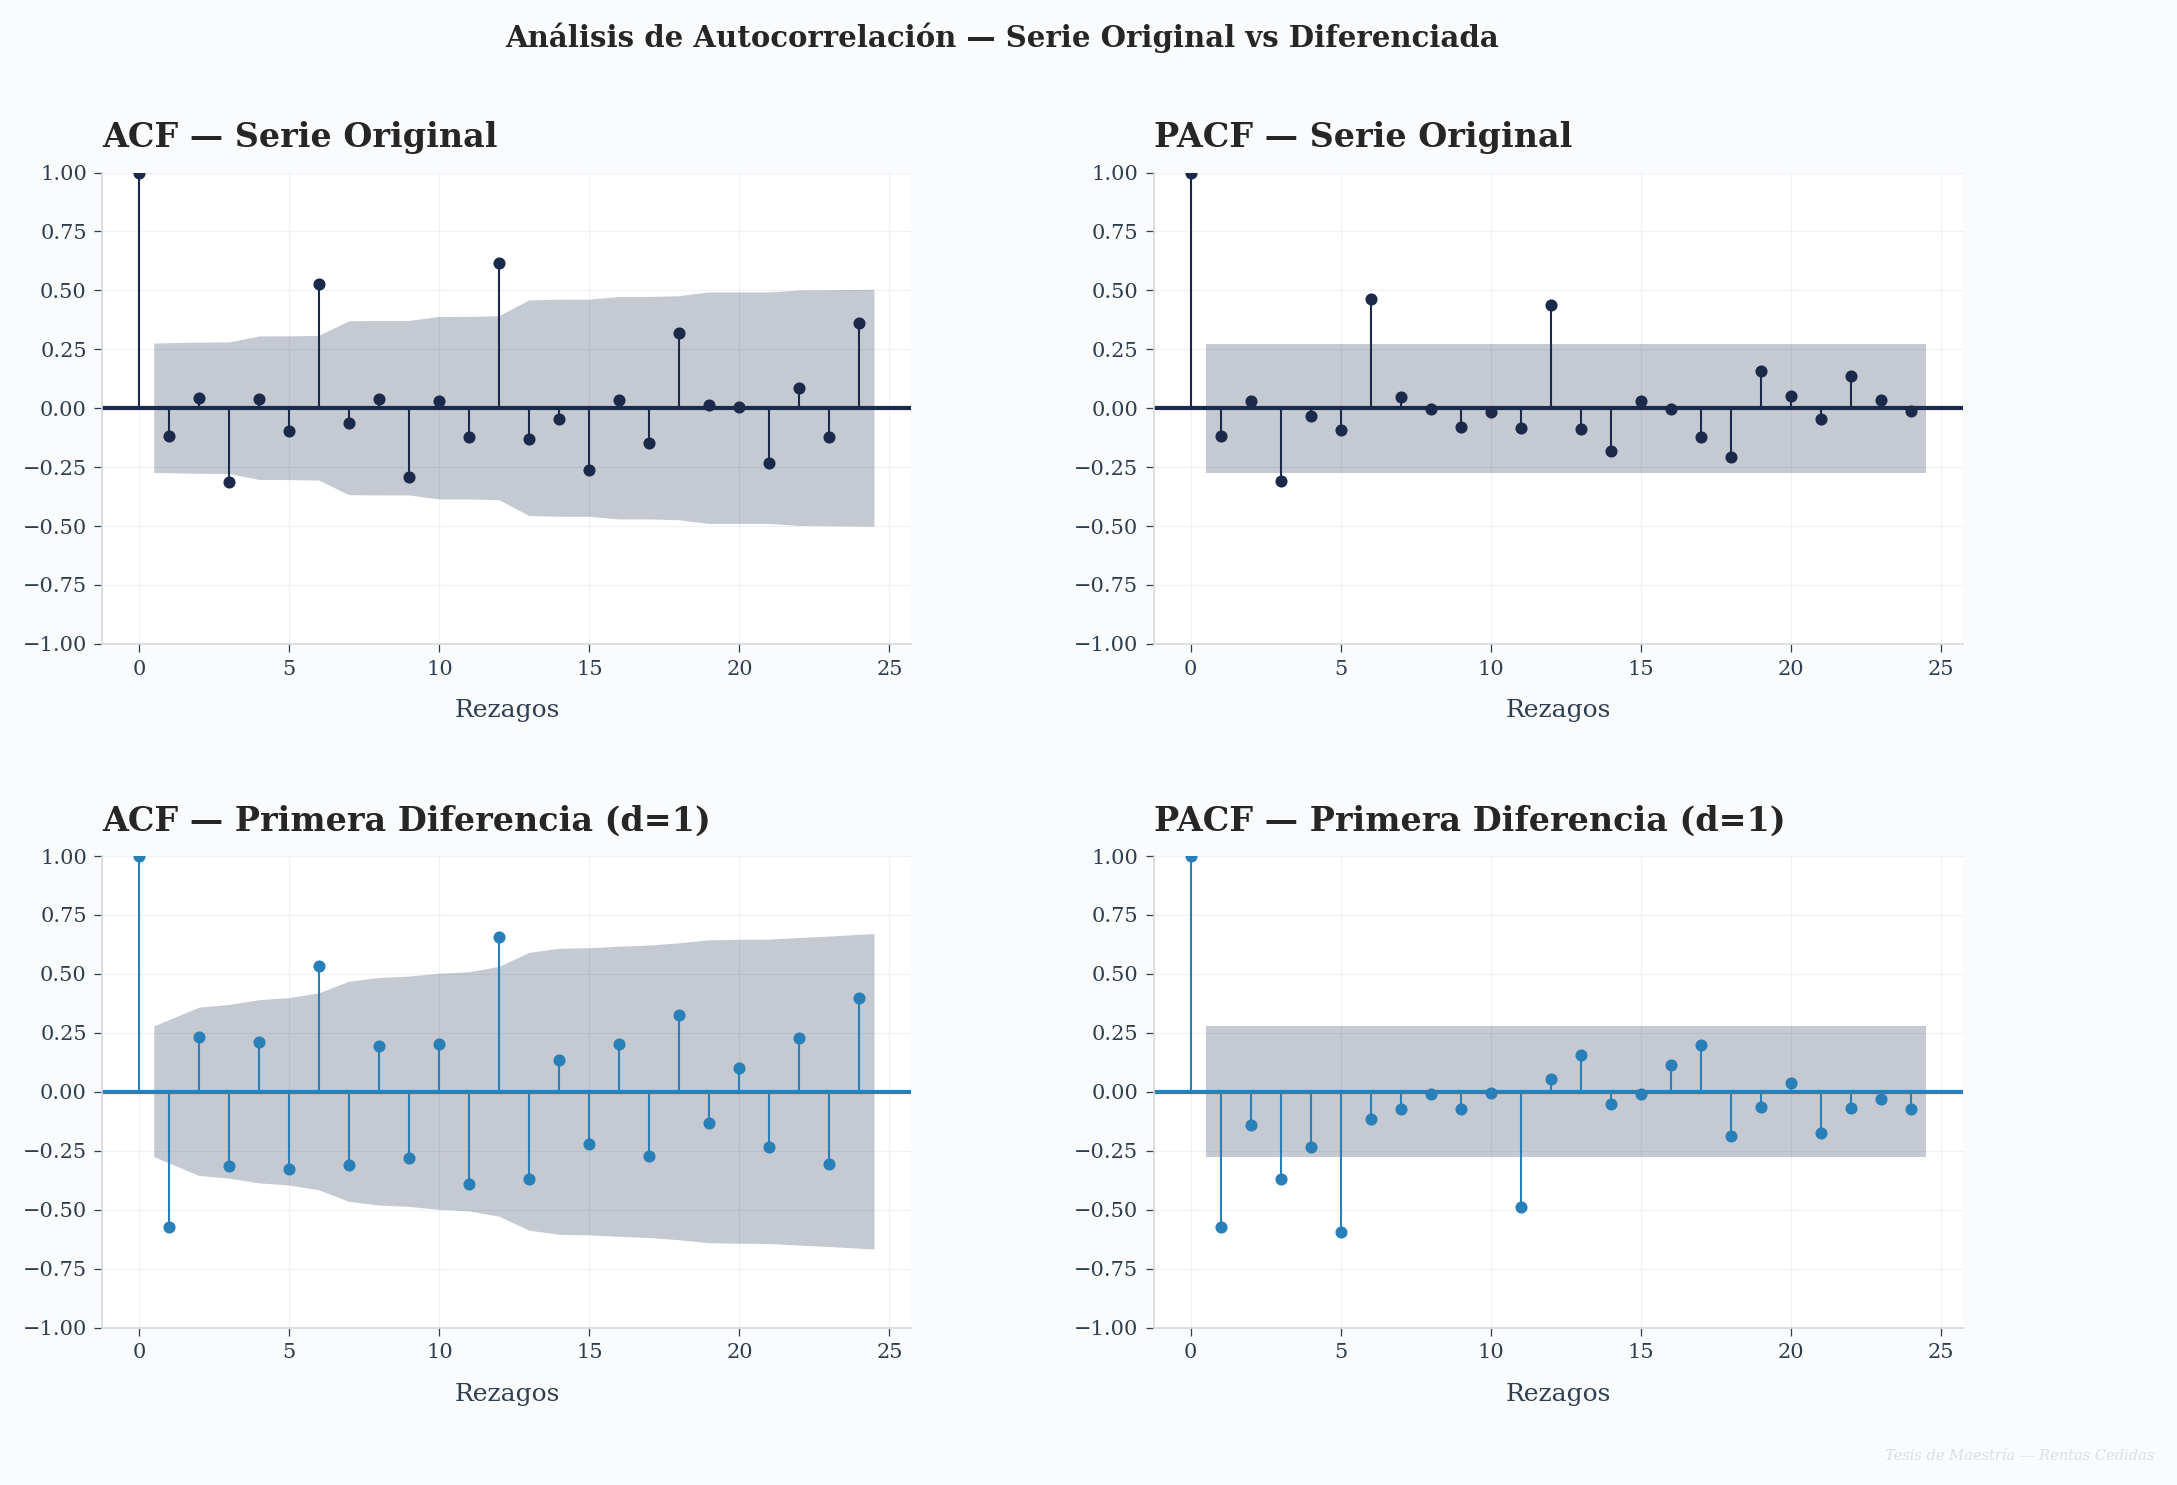


═════════════════════════════════════════════
INTERPRETACIÓN AUTOMÁTICA DE ACF/PACF
═════════════════════════════════════════════
  Lags ACF significativos (|ρ| > 0.274): [3, 6, 9, 12, 18, 24]
  → Lag 12 significativo: CONFIRMA estacionalidad anual (s=12)
  → Lags cortos significativos: sugiere componente AR/MA de orden bajo


In [15]:
# ── 3.3 ACF / PACF ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10),
                          gridspec_kw={'hspace': 0.45, 'wspace': 0.30})

# ACF (serie original)
plot_acf(serie_clean, ax=axes[0, 0], lags=min(24, len(serie_clean)//2 - 1),
         alpha=0.05, color=C_PRIMARY,
         vlines_kwargs={'colors': C_PRIMARY, 'linewidth': 1.0})
axes[0, 0].set_title('')  # limpiar título auto-generado por statsmodels
if _VIZ_THEME_LOADED:
    titulo_profesional(axes[0, 0], 'ACF — Serie Original')
else:
    axes[0, 0].set_title('ACF — Serie Original', fontweight='bold')

# PACF (serie original)
plot_pacf(serie_clean, ax=axes[0, 1], lags=min(24, len(serie_clean)//2 - 1),
          alpha=0.05, method='ywm', color=C_PRIMARY,
          vlines_kwargs={'colors': C_PRIMARY, 'linewidth': 1.0})
axes[0, 1].set_title('')
if _VIZ_THEME_LOADED:
    titulo_profesional(axes[0, 1], 'PACF — Serie Original')
else:
    axes[0, 1].set_title('PACF — Serie Original', fontweight='bold')

# Serie diferenciada (d=1)
serie_diff = serie_clean.diff().dropna()

# ACF (diferenciada)
plot_acf(serie_diff, ax=axes[1, 0], lags=min(24, len(serie_diff)//2 - 1),
         alpha=0.05, color=C_TERTIARY,
         vlines_kwargs={'colors': C_TERTIARY, 'linewidth': 1.0})
axes[1, 0].set_title('')
if _VIZ_THEME_LOADED:
    titulo_profesional(axes[1, 0], 'ACF — Primera Diferencia (d=1)')
else:
    axes[1, 0].set_title('ACF — Primera Diferencia', fontweight='bold')

# PACF (diferenciada)
plot_pacf(serie_diff, ax=axes[1, 1], lags=min(24, len(serie_diff)//2 - 1),
          alpha=0.05, method='ywm', color=C_TERTIARY,
          vlines_kwargs={'colors': C_TERTIARY, 'linewidth': 1.0})
axes[1, 1].set_title('')
if _VIZ_THEME_LOADED:
    titulo_profesional(axes[1, 1], 'PACF — Primera Diferencia (d=1)')
else:
    axes[1, 1].set_title('PACF — Primera Diferencia', fontweight='bold')

for ax in axes.flat:
    ax.set_xlabel('Rezagos')

fig.suptitle('Análisis de Autocorrelación — Serie Original vs Diferenciada',
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '01_acf_pacf', OUTPUTS_FIGURES)
plt.show()

# Interpretación automática
print("\n═════════════════════════════════════════════")
print("INTERPRETACIÓN AUTOMÁTICA DE ACF/PACF")
print("═════════════════════════════════════════════")
from statsmodels.tsa.stattools import acf, pacf
acf_vals = acf(serie_clean, nlags=min(24, len(serie_clean)//2 - 1), alpha=0.05)
n = len(serie_clean)
ci = 1.96 / np.sqrt(n)
sig_lags = [i for i in range(1, len(acf_vals[0])) if abs(acf_vals[0][i]) > ci]
print(f"  Lags ACF significativos (|\u03c1| > {ci:.3f}): {sig_lags}")
if 12 in sig_lags:
    print(f"  \u2192 Lag 12 significativo: CONFIRMA estacionalidad anual (s=12)")
if any(l in sig_lags for l in [1, 2, 3]):
    print(f"  \u2192 Lags cortos significativos: sugiere componente AR/MA de orden bajo")


### 3.4  Análisis de distribución

Se evalúa la distribución marginal de la serie mensual para determinar
si se requieren transformaciones (log, Box-Cox) antes del modelado.
Se aplican la prueba de **Jarque-Bera** (normalidad) y se calculan los
momentos de tercer y cuarto orden (asimetría, curtosis).


  📊 Figura guardada: 01_distribucion.png


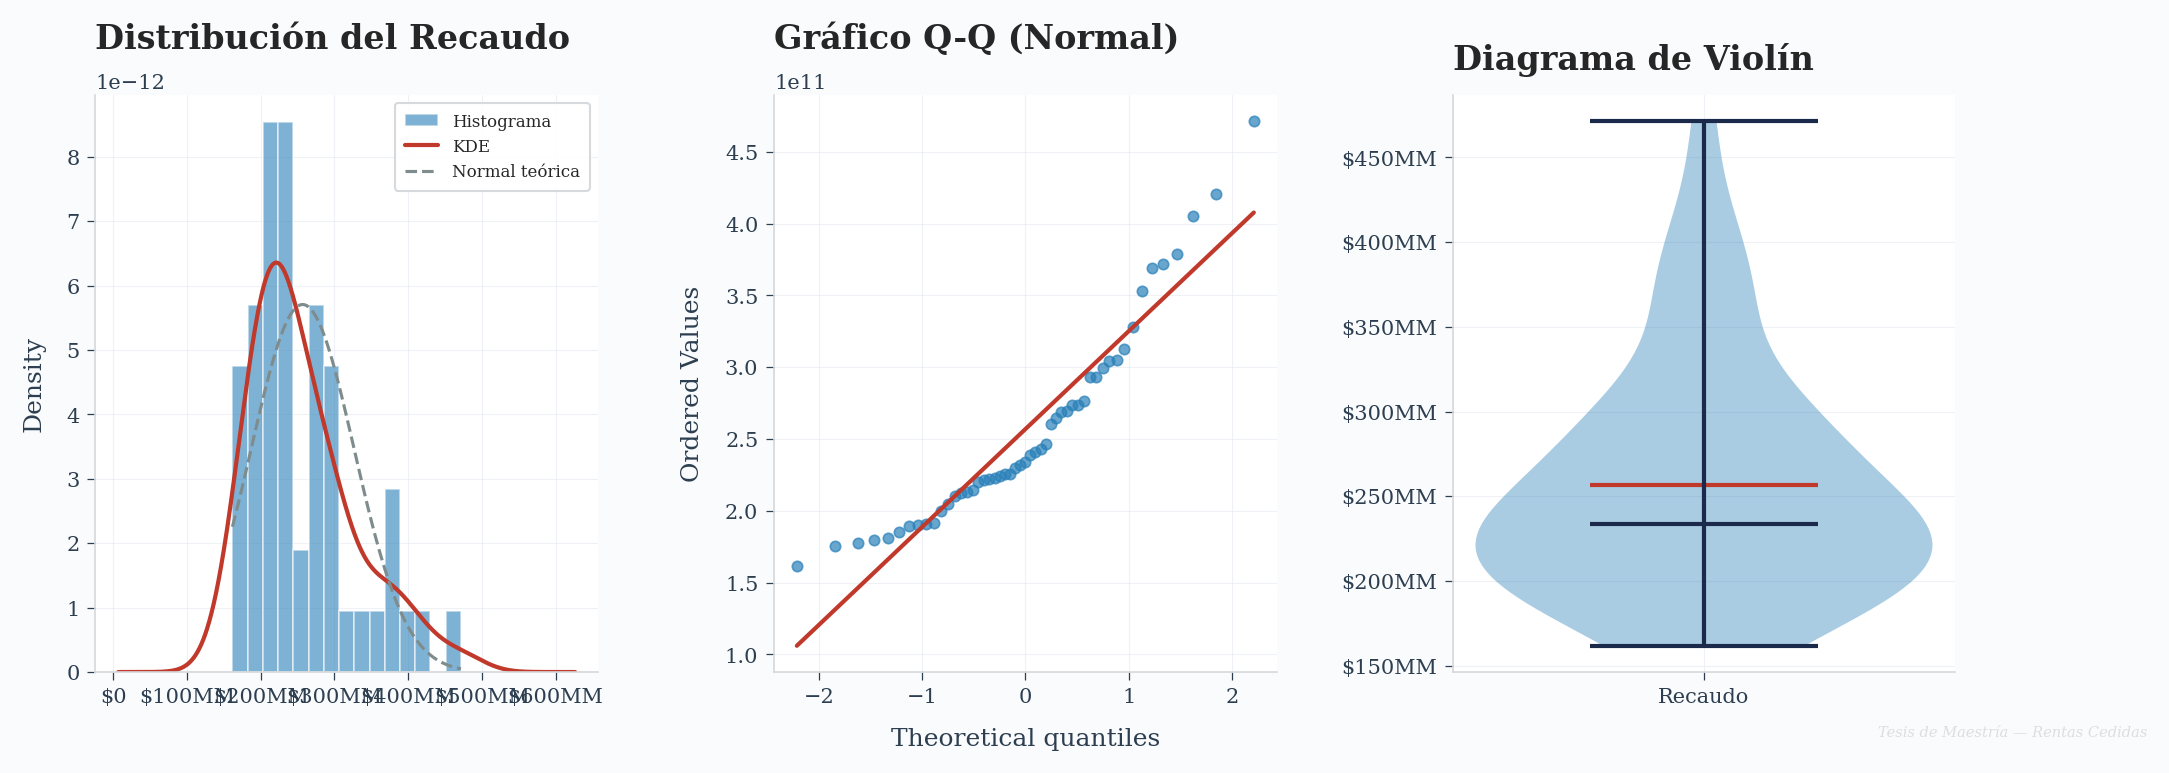


══════════════════════════════════════════════════
PRUEBAS DE NORMALIDAD
══════════════════════════════════════════════════
  Asimetría (Skewness): 1.1108  → Asimétrica positiva
  Curtosis (exceso):    0.7596  → Mesocúrtica
  Jarque-Bera:          stat=11.7137, p=0.002860  → NO Normal
  Shapiro-Wilk:         stat=0.9039, p=0.000571  → NO Normal


In [17]:
# ── 3.4 Distribución de la serie ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5),
                          gridspec_kw={'wspace': 0.35})

# Histograma + KDE
axes[0].hist(serie_clean, bins=15, density=True, alpha=0.6, color=C_TERTIARY,
             edgecolor='white', linewidth=0.8, label='Histograma')
serie_clean.plot.kde(ax=axes[0], color=C_SECONDARY, linewidth=2, label='KDE')
# Normal teórica
x_range = np.linspace(serie_clean.min(), serie_clean.max(), 100)
axes[0].plot(x_range, stats.norm.pdf(x_range, serie_clean.mean(), serie_clean.std()),
             color=C_TEXT_LIGHT, ls='--', lw=1.5, label='Normal teórica')
if _VIZ_THEME_LOADED:
    titulo_profesional(axes[0], 'Distribución del Recaudo')
    formato_pesos_eje(axes[0], eje='x')
else:
    axes[0].set_title('Distribución', fontweight='bold')
axes[0].legend(fontsize=8)

# Q-Q Plot
stats.probplot(serie_clean.values, dist='norm', plot=axes[1])
# Limpiar TODOS los títulos auto-generados por probplot (center + left)
axes[1].set_title('', loc='center')
axes[1].set_title('', loc='left')
axes[1].get_lines()[0].set(color=C_TERTIARY, markersize=5, alpha=0.7)
axes[1].get_lines()[1].set(color=C_SECONDARY, linewidth=2)
if _VIZ_THEME_LOADED:
    titulo_profesional(axes[1], 'Gráfico Q-Q (Normal)')
else:
    axes[1].set_title('Gráfico Q-Q', fontweight='bold')

# Box-Violin
parts = axes[2].violinplot(serie_clean.values, positions=[0], showmeans=True,
                            showmedians=True, showextrema=True)
for pc in parts['bodies']:
    pc.set_facecolor(C_TERTIARY)
    pc.set_alpha(0.4)
parts['cmeans'].set_color(C_SECONDARY)
parts['cmedians'].set_color(C_PRIMARY)
if _VIZ_THEME_LOADED:
    titulo_profesional(axes[2], 'Diagrama de Violín')
    formato_pesos_eje(axes[2])
else:
    axes[2].set_title('Diagrama de Violín', fontweight='bold')
axes[2].set_xticks([0])
axes[2].set_xticklabels(['Recaudo'])

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '01_distribucion', OUTPUTS_FIGURES)
plt.show()

# Tests de normalidad
jb_stat, jb_p = stats.jarque_bera(serie_clean.values)
shap_stat, shap_p = stats.shapiro(serie_clean.values)
skewness = stats.skew(serie_clean.values)
kurt = stats.kurtosis(serie_clean.values)

print(f"\n{'═' * 50}")
print(f"PRUEBAS DE NORMALIDAD")
print(f"{'═' * 50}")
print(f"  Asimetría (Skewness): {skewness:.4f}  {'→ Asimétrica positiva' if skewness > 0.5 else '→ Asimétrica negativa' if skewness < -0.5 else '→ Aproximadamente simétrica'}")
print(f"  Curtosis (exceso):    {kurt:.4f}  {'→ Leptocúrtica (colas pesadas)' if kurt > 1 else '→ Platocúrtica' if kurt < -1 else '→ Mesocúrtica'}")
print(f"  Jarque-Bera:          stat={jb_stat:.4f}, p={jb_p:.6f}  {'→ NO Normal' if jb_p < 0.05 else '→ Normal'}")
print(f"  Shapiro-Wilk:         stat={shap_stat:.4f}, p={shap_p:.6f}  {'→ NO Normal' if shap_p < 0.05 else '→ Normal'}")

---
## Fase IV — Análisis en Valores Reales, Crecimiento Interanual y Correlación Macro
### 4.1  Deflación con IPC — Serie en valores reales

El recaudo nominal está afectado por la inflación acumulada. Para aislar el
crecimiento **real** del recaudo, se deflacta la serie utilizando el IPC anual
registrado en `MACRO_DATA`. Se construye un **índice de precios base 2021** y se
calcula:

$$\text{Recaudo Real}_t = \frac{\text{Recaudo Nominal}_t}{\text{Índice IPC}_t} \times 100$$


Índice de Precios (base 2021 = 100):
  2021: 100.00  (IPC interanual: 5.62%)
  2022: 113.12  (IPC interanual: 13.12%)
  2023: 123.62  (IPC interanual: 9.28%)
  2024: 130.05  (IPC interanual: 5.20%)
  2025: 136.68  (IPC interanual: 5.10%)
  2026: 143.65  (IPC interanual: 5.10%)


  📊 Figura guardada: 01_nominal_vs_real.png


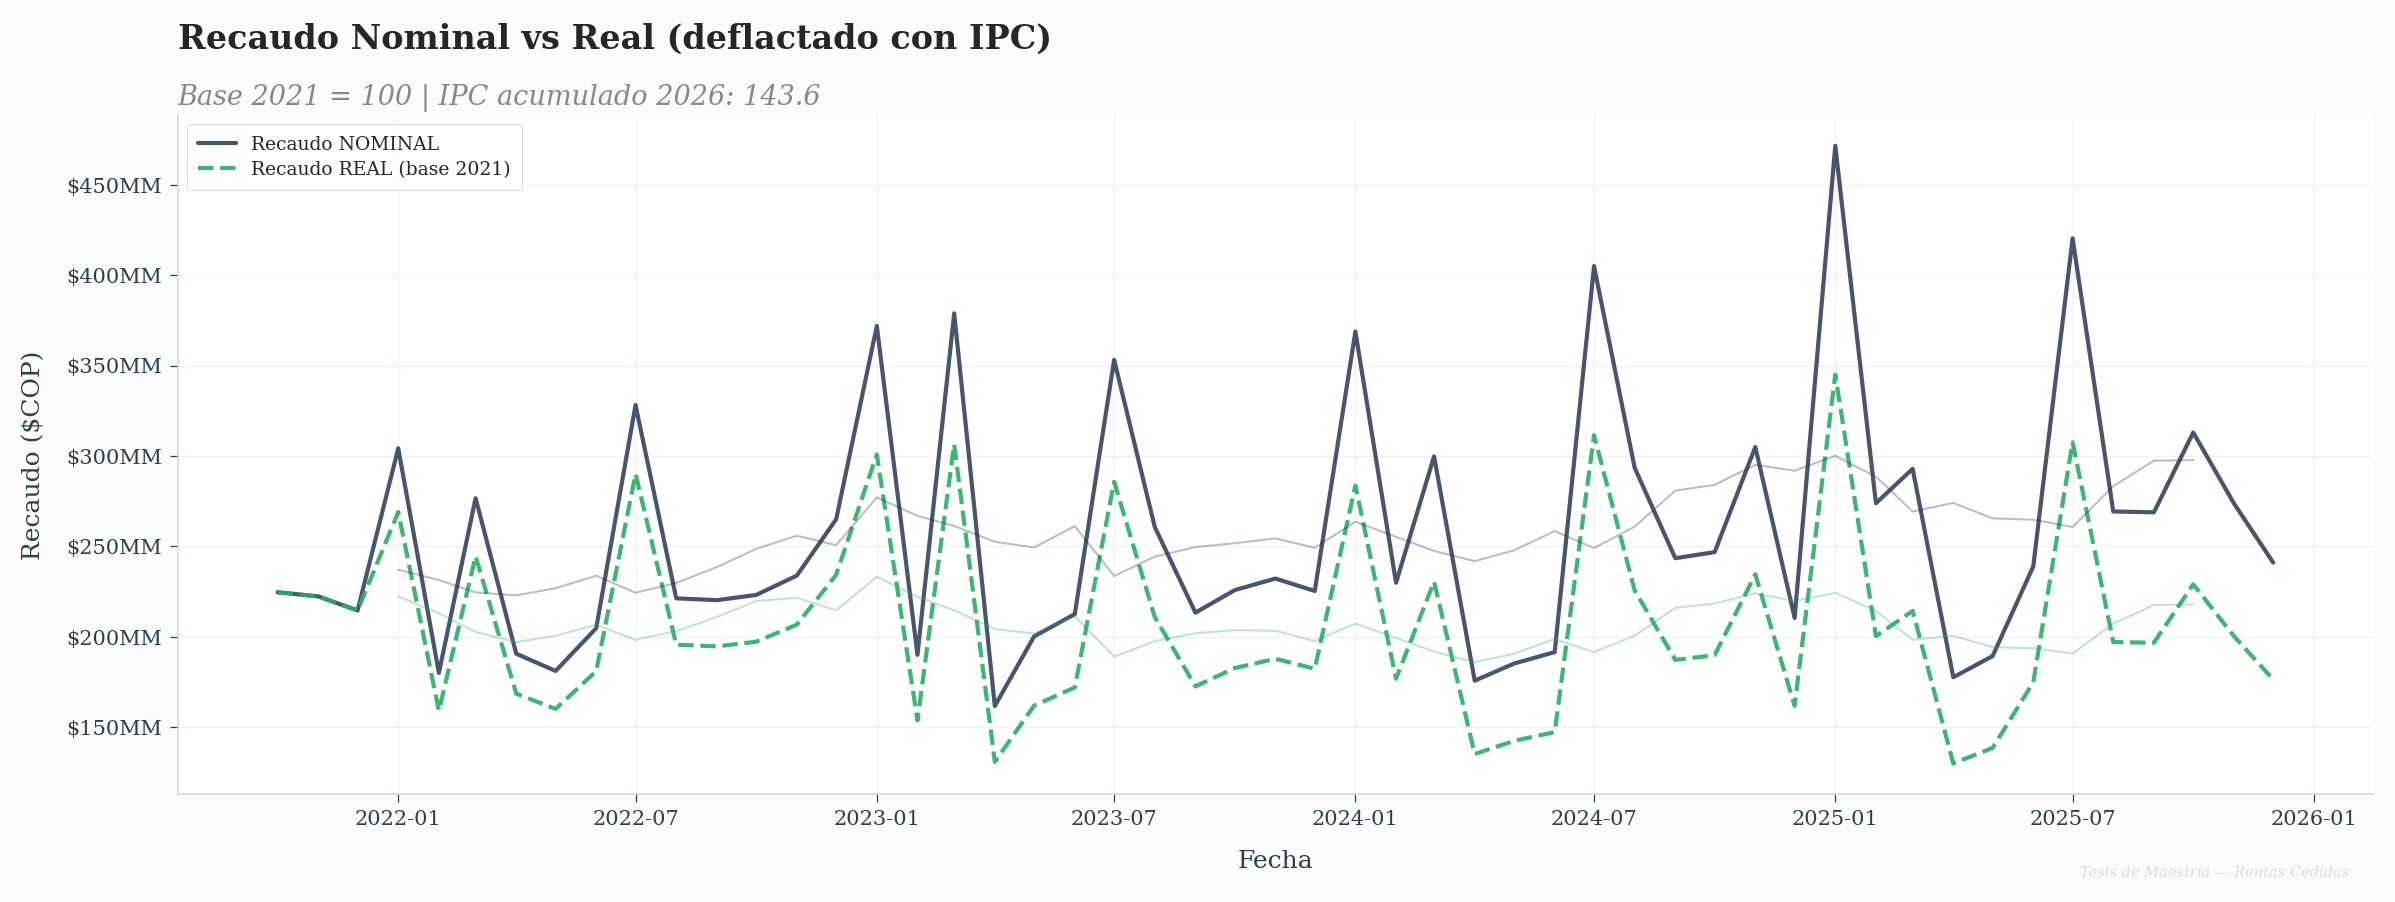


  Crecimiento nominal punta-a-punta: +7.3%
  Crecimiento real punta-a-punta:    -21.5%
  Diferencia (efecto inflación):     +28.8 pp


In [12]:
# ── 4.1 Deflación con IPC ─────────────────────────────────────────
# Construir índice de precios (base 2021 = 100)
años = sorted(MACRO_DATA.keys())
ipc_dict = {a: MACRO_DATA[a]['IPC'] for a in años}

# Índice acumulado: 2021=100, 2022=100*(1+IPC_2022/100), etc.
indice_ipc = {}
base = 100
for a in años:
    if a == años[0]:
        indice_ipc[a] = base
    else:
        base = base * (1 + ipc_dict[a] / 100)
        indice_ipc[a] = base

print("Índice de Precios (base 2021 = 100):")
for a, idx in indice_ipc.items():
    print(f"  {a}: {idx:.2f}  (IPC interanual: {ipc_dict[a]:.2f}%)")

# Deflactar serie mensual
df_mensual['IPC_Indice'] = df_mensual['Año'].map(indice_ipc)
df_mensual['Recaudo_Real'] = df_mensual['Recaudo_Total'] / df_mensual['IPC_Indice'] * 100

# Visualización nominal vs real
fig, ax = plt.subplots(figsize=FIGSIZE_WIDE if _VIZ_THEME_LOADED else (16, 6))

ax.plot(df_mensual.index, df_mensual['Recaudo_Total'], color=C_PRIMARY,
        linewidth=2, label='Recaudo NOMINAL', alpha=0.8)
ax.plot(df_mensual.index, df_mensual['Recaudo_Real'], color=C_QUATERNARY,
        linewidth=2, ls='--', label='Recaudo REAL (base 2021)', alpha=0.9)

# Media móvil para ambas
ma_nom = df_mensual['Recaudo_Total'].rolling(6, center=True).mean()
ma_real = df_mensual['Recaudo_Real'].rolling(6, center=True).mean()
ax.plot(df_mensual.index, ma_nom, color=C_PRIMARY, linewidth=1, alpha=0.3)
ax.plot(df_mensual.index, ma_real, color=C_QUATERNARY, linewidth=1, alpha=0.3)

if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Recaudo Nominal vs Real (deflactado con IPC)',
                       f'Base 2021 = 100 | IPC acumulado {años[-1]}: {indice_ipc[años[-1]]:.1f}')
    formato_pesos_eje(ax)
    leyenda_profesional(ax, loc='upper left')
    marca_agua(fig)
    guardar_figura(fig, '01_nominal_vs_real', OUTPUTS_FIGURES)
else:
    ax.set_title('Recaudo Nominal vs Real', fontweight='bold')
    ax.legend()

ax.set_xlabel('Fecha')
ax.set_ylabel('Recaudo ($COP)')
plt.tight_layout()
plt.show()

# Crecimiento real acumulado
crec_real = ((df_mensual['Recaudo_Real'].iloc[-1] / df_mensual['Recaudo_Real'].iloc[0]) - 1) * 100
crec_nom = ((df_mensual['Recaudo_Total'].iloc[-1] / df_mensual['Recaudo_Total'].iloc[0]) - 1) * 100
print(f"\n  Crecimiento nominal punta-a-punta: {crec_nom:+.1f}%")
print(f"  Crecimiento real punta-a-punta:    {crec_real:+.1f}%")
print(f"  Diferencia (efecto inflación):     {crec_nom - crec_real:+.1f} pp")


### 4.2  Crecimiento interanual (YoY)

Se calcula la tasa de crecimiento interanual $g_t = (Y_t / Y_{t-12} - 1) \times 100$
para meses con datos completos disponibles. Este indicador permite:
- Identificar **aceleraciones** o **desaceleraciones** del recaudo.
- Comparar con tasas de crecimiento de variables macro (IPC, Salario, Consumo).


  📊 Figura guardada: 01_crecimiento_yoy.png


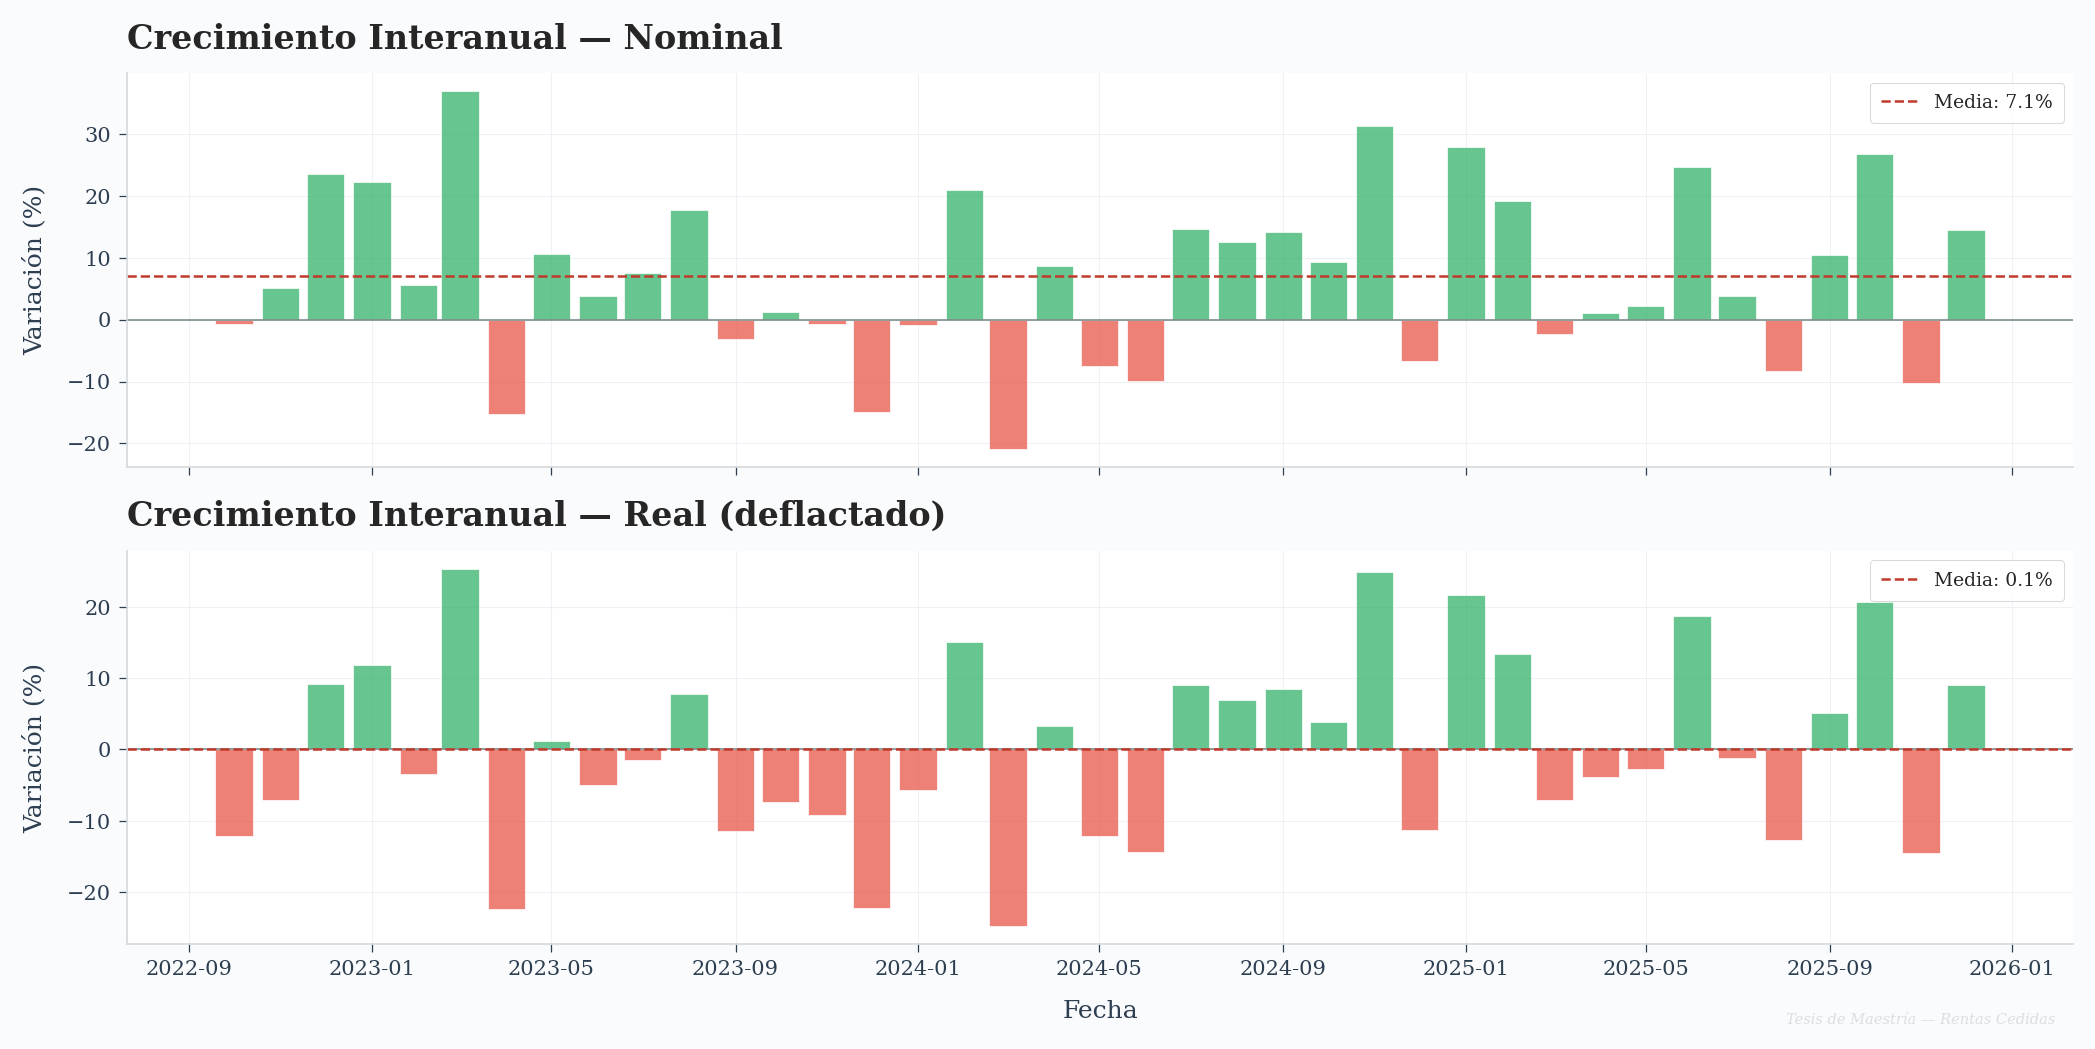


═════════════════════════════════════════════════════
RESUMEN POR AÑO
═════════════════════════════════════════════════════
      Recaudo_Nominal  Recaudo_Real  Meses  Promedio_Mesl     CV
Año                                                             
2021     6.614844e+11  6.614844e+11      3   2.204948e+11   2.40
2022     2.829001e+12  2.500885e+12     12   2.357501e+11  20.41
2023     3.025867e+12  2.447765e+12     12   2.521556e+11  29.37
2024     3.155099e+12  2.426148e+12     12   2.629249e+11  27.79
2025     3.430680e+12  2.510046e+12     12   2.858900e+11  29.74


In [13]:
# ── 4.2 Crecimiento interanual (YoY) ─────────────────────────────
df_mensual['YoY'] = df_mensual['Recaudo_Total'].pct_change(periods=12) * 100
df_mensual['YoY_Real'] = df_mensual['Recaudo_Real'].pct_change(periods=12) * 100

# Solo meses con YoY disponible
yoy_valid = df_mensual.dropna(subset=['YoY'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=FIGSIZE_FULL if _VIZ_THEME_LOADED else (14, 8),
                                sharex=True)

# Panel 1: barras YoY nominal
colores_yoy = [C_POSITIVE if v >= 0 else C_NEGATIVE for v in yoy_valid['YoY']]
ax1.bar(yoy_valid.index, yoy_valid['YoY'], color=colores_yoy, alpha=0.7,
        edgecolor='white', linewidth=0.5, width=25)
ax1.axhline(0, color=C_TEXT_LIGHT, ls='-', lw=0.8)
ax1.axhline(yoy_valid['YoY'].mean(), color=C_SECONDARY, ls='--', lw=1.2,
            label=f'Media: {yoy_valid["YoY"].mean():.1f}%')
if _VIZ_THEME_LOADED:
    titulo_profesional(ax1, 'Crecimiento Interanual — Nominal')
    leyenda_profesional(ax1)
else:
    ax1.set_title('Crecimiento Interanual NOMINAL', fontweight='bold')
    ax1.legend()
ax1.set_ylabel('Variación (%)')

# Panel 2: barras YoY real
yoy_real_valid = df_mensual.dropna(subset=['YoY_Real'])
colores_yoy_r = [C_POSITIVE if v >= 0 else C_NEGATIVE for v in yoy_real_valid['YoY_Real']]
ax2.bar(yoy_real_valid.index, yoy_real_valid['YoY_Real'], color=colores_yoy_r,
        alpha=0.7, edgecolor='white', linewidth=0.5, width=25)
ax2.axhline(0, color=C_TEXT_LIGHT, ls='-', lw=0.8)
ax2.axhline(yoy_real_valid['YoY_Real'].mean(), color=C_SECONDARY, ls='--', lw=1.2,
            label=f'Media: {yoy_real_valid["YoY_Real"].mean():.1f}%')
if _VIZ_THEME_LOADED:
    titulo_profesional(ax2, 'Crecimiento Interanual — Real (deflactado)')
    leyenda_profesional(ax2)
else:
    ax2.set_title('Crecimiento Interanual REAL', fontweight='bold')
    ax2.legend()
ax2.set_ylabel('Variación (%)')
ax2.set_xlabel('Fecha')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '01_crecimiento_yoy', OUTPUTS_FIGURES)
plt.show()

# Tabla resumen por año
print("\n═════════════════════════════════════════════════════")
print("RESUMEN POR AÑO")
print("═════════════════════════════════════════════════════")
resumen_anual = df_mensual.groupby('Año').agg(
    Recaudo_Nominal=('Recaudo_Total', 'sum'),
    Recaudo_Real=('Recaudo_Real', 'sum'),
    Meses=('Recaudo_Total', 'count'),
    Promedio_Mesl=('Recaudo_Total', 'mean'),
    CV=('Recaudo_Total', lambda x: x.std()/x.mean()*100)
).round(2)
print(resumen_anual.to_string())


### 4.3  Concentración del recaudo — Análisis de Pareto

Se examina la **concentración** del recaudo por entidad aportante y por
concepto, para identificar si un pequeño número de contribuyentes genera
la mayor parte del ingreso (principio de Pareto 80/20).


  📊 Figura guardada: 01_top15_entidades.png


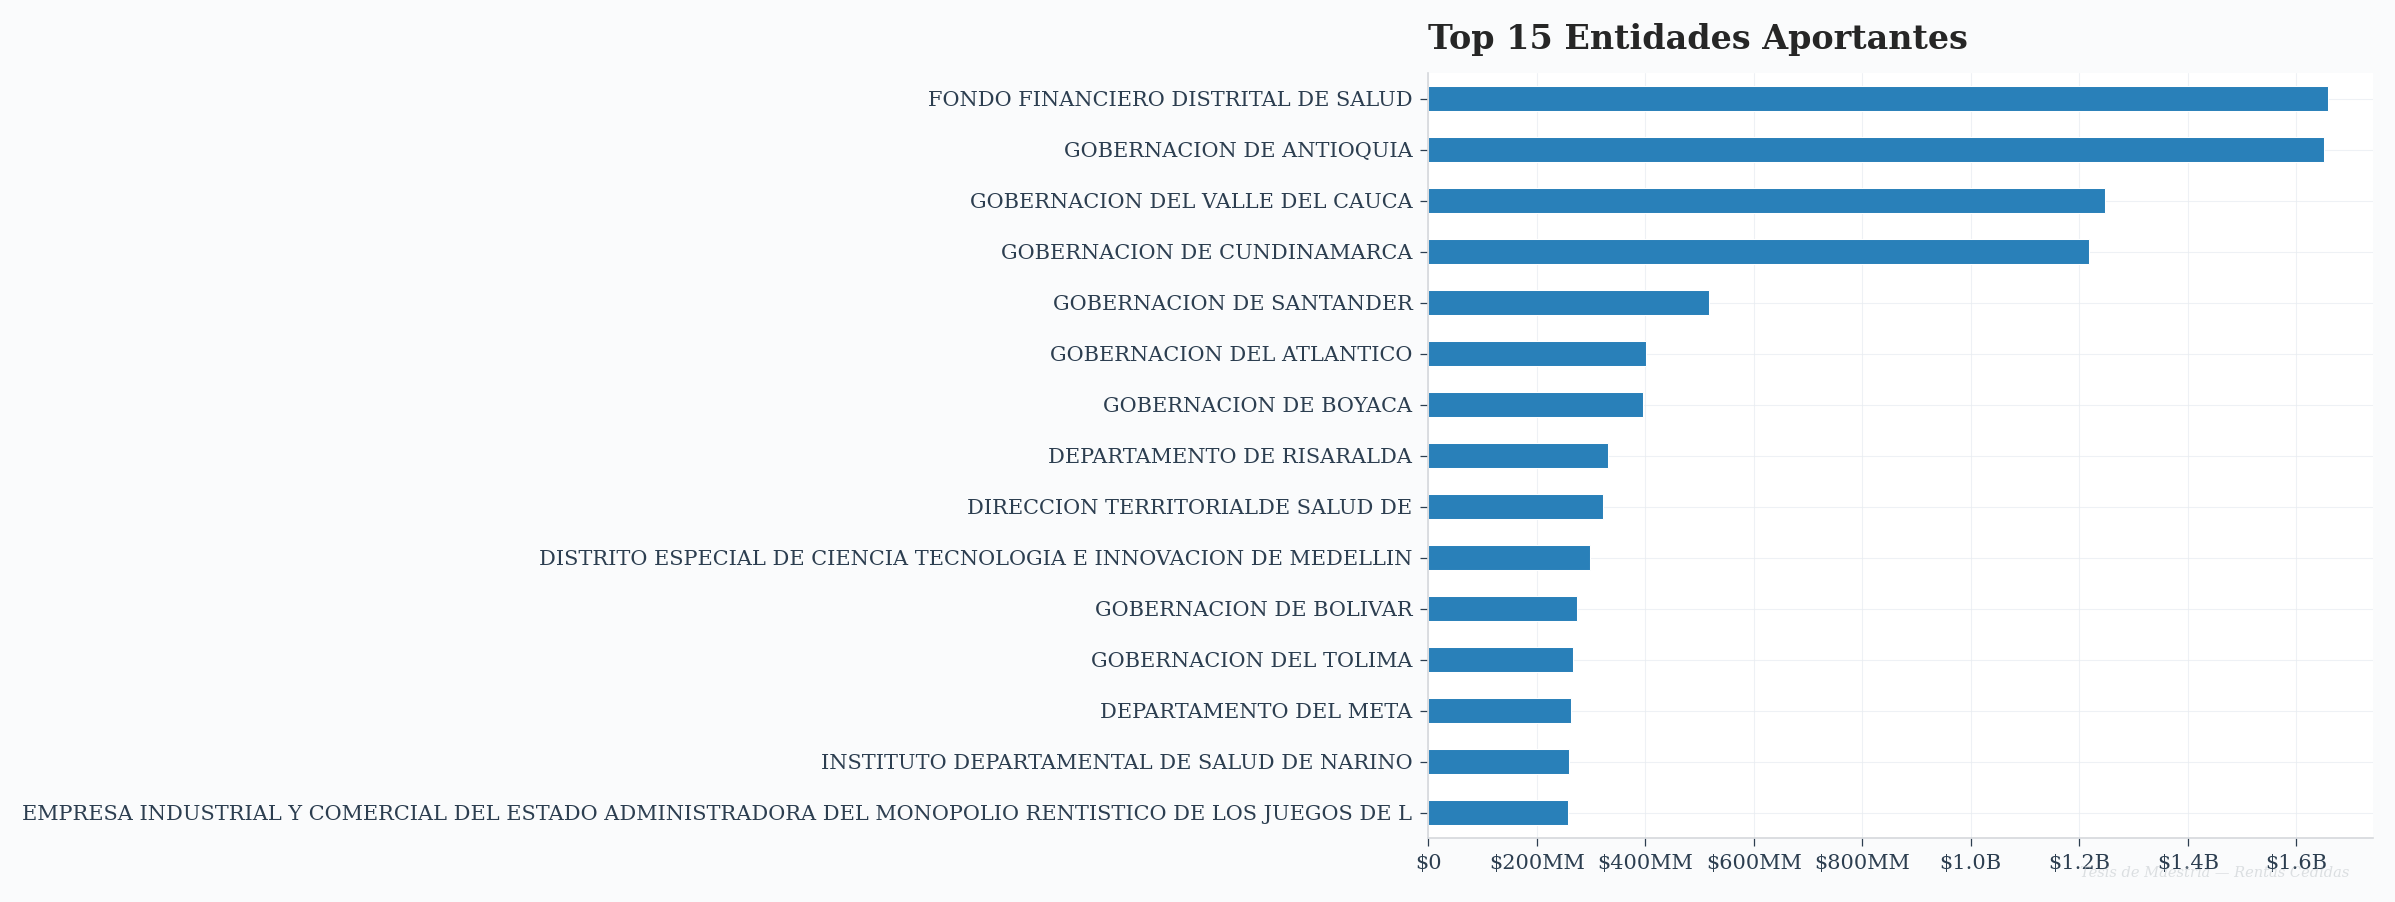


  Las 5 principales entidades concentran: 48.0% del recaudo total


In [18]:
# ── 4.3a Top 15 Entidades Aportantes ─────────────────────────────
top_entidades = (df.groupby('NombreBeneficiarioAportante')[COL_VALOR]
                 .sum().sort_values(ascending=False).head(15))
total_recaudo = df[COL_VALOR].sum()

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)

top_entidades.sort_values().plot.barh(ax=ax, color=C_TERTIARY, edgecolor='white', linewidth=0.5)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Top 15 Entidades Aportantes')
    formato_pesos_eje(ax, eje='x')
else:
    ax.set_title('Top 15 Entidades Aportantes', fontweight='bold')
ax.set_ylabel('')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '01_top15_entidades', OUTPUTS_FIGURES)
plt.show()

# Top 5 concentración
top5_pct = top_entidades.head(5).sum() / total_recaudo * 100
print(f"\n  Las 5 principales entidades concentran: {top5_pct:.1f}% del recaudo total")

  📊 Figura guardada: 01_pareto_subgrupo.png


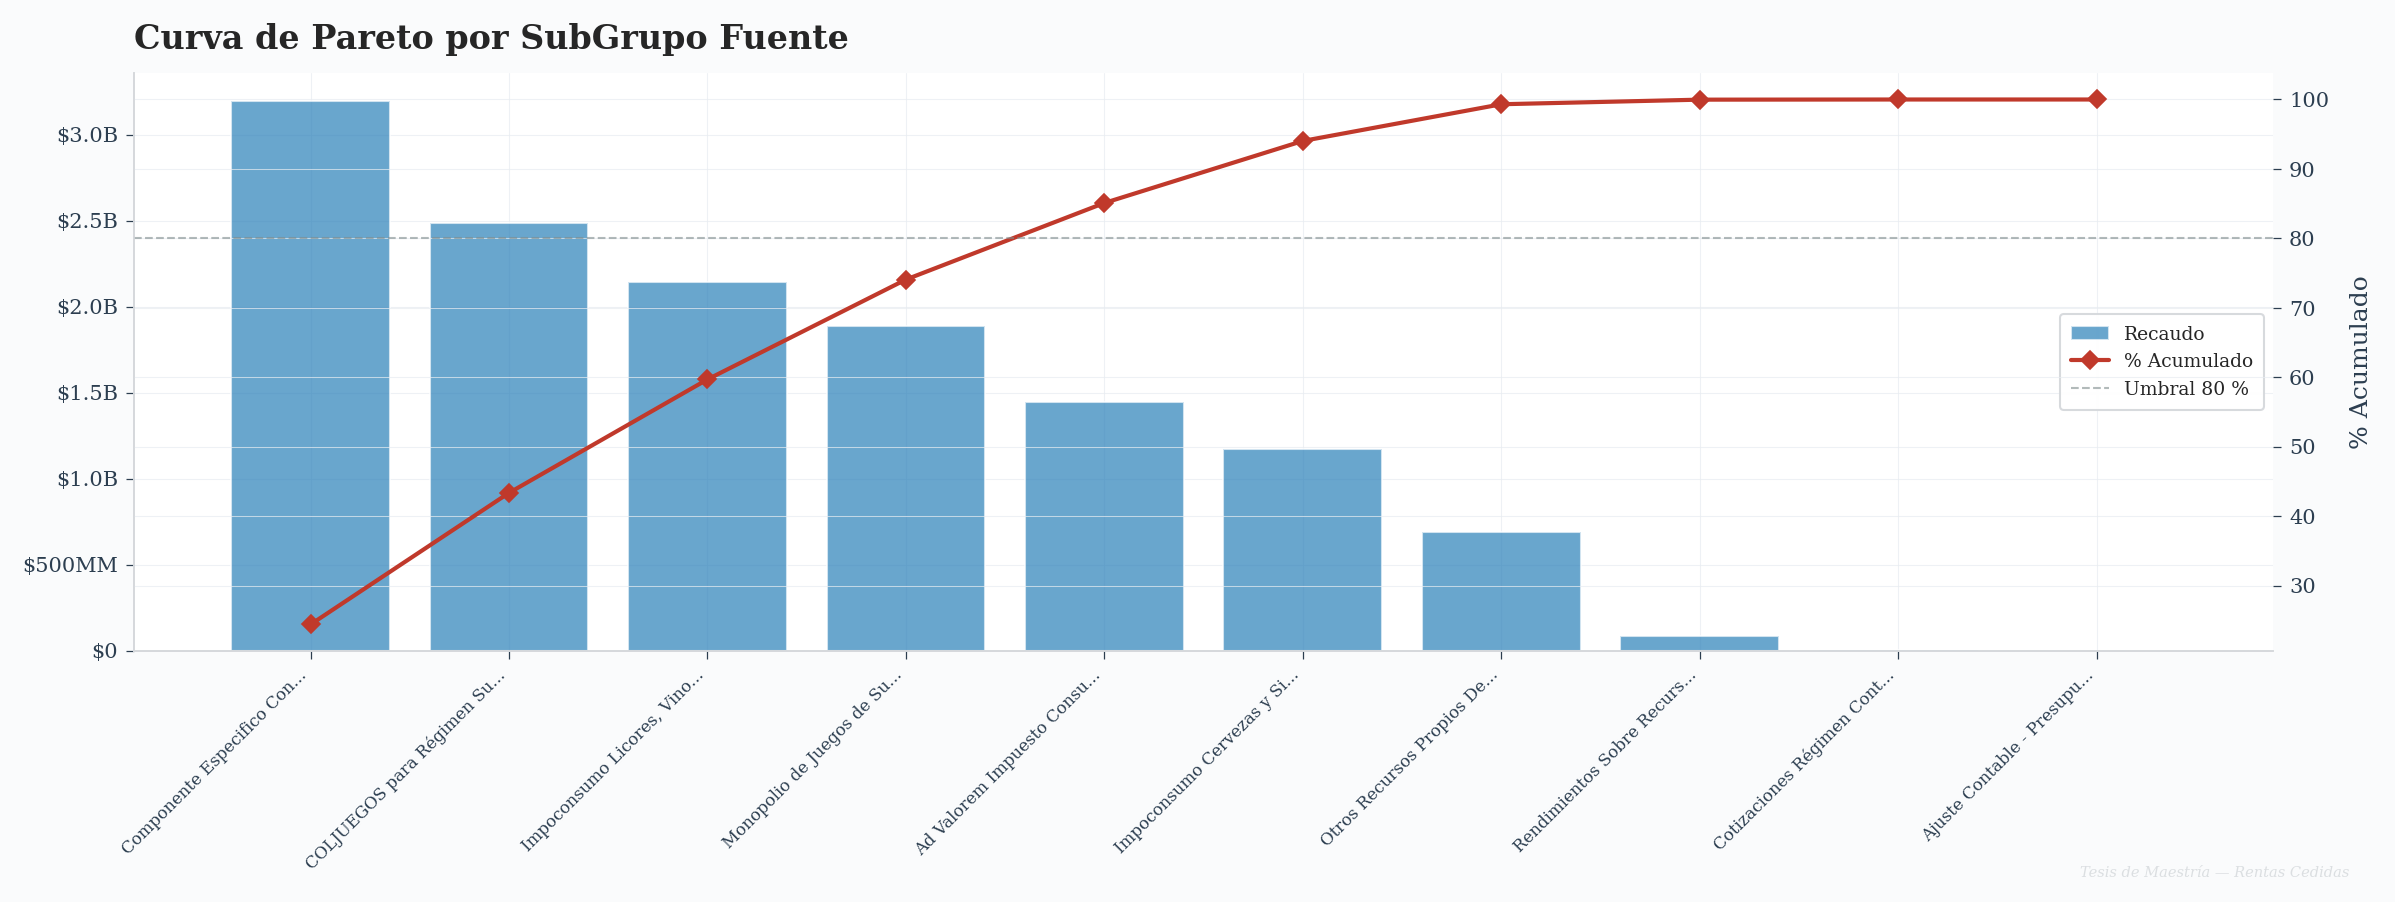


  Coeficiente de Gini (por SubGrupo Fuente): 0.4599
  → Alta concentración
  SubGrupos que explican >= 80% del recaudo: 5 de 10


In [19]:
# ── 4.3b Curva de Pareto por SubGrupo Fuente ─────────────────────
por_concepto = (df.groupby('NombreSubGrupoFuente')[COL_VALOR]
                .sum().sort_values(ascending=False))
pct_acum = por_concepto.cumsum() / total_recaudo * 100

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)

ax.bar(range(len(por_concepto)), por_concepto.values, color=C_TERTIARY,
       alpha=0.7, edgecolor='white', label='Recaudo')
ax_twin = ax.twinx()
ax_twin.plot(range(len(por_concepto)), pct_acum.values, color=C_SECONDARY,
             marker='D', linewidth=2, markersize=6, label='% Acumulado')
ax_twin.axhline(80, color=C_TEXT_LIGHT, ls='--', lw=1, alpha=0.6, label='Umbral 80 %')
ax_twin.set_ylabel('% Acumulado')

ax.set_xticks(range(len(por_concepto)))
ax.set_xticklabels([s[:25] + '...' if len(s) > 25 else s for s in por_concepto.index],
                    rotation=45, ha='right', fontsize=8)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Curva de Pareto por SubGrupo Fuente')
    formato_pesos_eje(ax)
else:
    ax.set_title('Curva de Pareto por SubGrupo Fuente', fontweight='bold')

# Combinar leyendas
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax_twin.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=9)

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '01_pareto_subgrupo', OUTPUTS_FIGURES)
plt.show()

# Gini
sorted_vals = np.sort(por_concepto.values)
n = len(sorted_vals)
cumx = np.cumsum(sorted_vals)
gini = (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n
print(f"\n  Coeficiente de Gini (por SubGrupo Fuente): {gini:.4f}")
print(f"  → {'Alta concentración' if gini > 0.4 else 'Concentración moderada' if gini > 0.2 else 'Distribución dispersa'}")

# SubGrupos que cubren el 80 %
n_80 = (pct_acum <= 80).sum() + 1
print(f"  SubGrupos que explican >= 80% del recaudo: {n_80} de {len(por_concepto)}")

### 4.4  Correlación con variables macroeconómicas

Se construye una tabla anual de recaudo vs. indicadores macroeconómicos
(IPC, Salario Mínimo, UPC, Consumo de Hogares) para explorar posibles
relaciones que justifiquen el uso de regresores exógenos en modelos
SARIMAX y XGBoost.

> **Nota metodológica.** Con solo 4–5 años completos, los coeficientes de
> correlación son indicativos pero no concluyentes. El análisis formal
> se profundiza en el notebook `03_Correlacion_Macro.ipynb`.


════════════════════════════════════════════════════════════
TABLA RECAUDO ANUAL vs MACRO
════════════════════════════════════════════════════════════
        IPC  Salario_Minimo    UPC  Consumo_Hogares  Desempleo  Recaudo_Anual
Año                                                                          
2022  13.12           10.07   5.42            10.79       11.2   2.829001e+12
2023   9.28           16.00  16.23             0.38       10.2   3.025867e+12
2024   5.20           12.07  12.01             1.60        9.8   3.155099e+12
2025   5.10            9.54   8.00             2.60        9.5   3.430680e+12

────────────────────────────────────────────────────────────
CORRELACIONES con Recaudo Anual
────────────────────────────────────────────────────────────
  IPC                  r = -0.8982  ★★★ Fuerte
  Salario_Minimo       r = -0.2615  ★ Débil
  UPC                  r = +0.0592  ★ Débil
  Consumo_Hogares      r = -0.6049  ★★ Moderada


  📊 Figura guardada: 01_correlacion_macro_preview.png


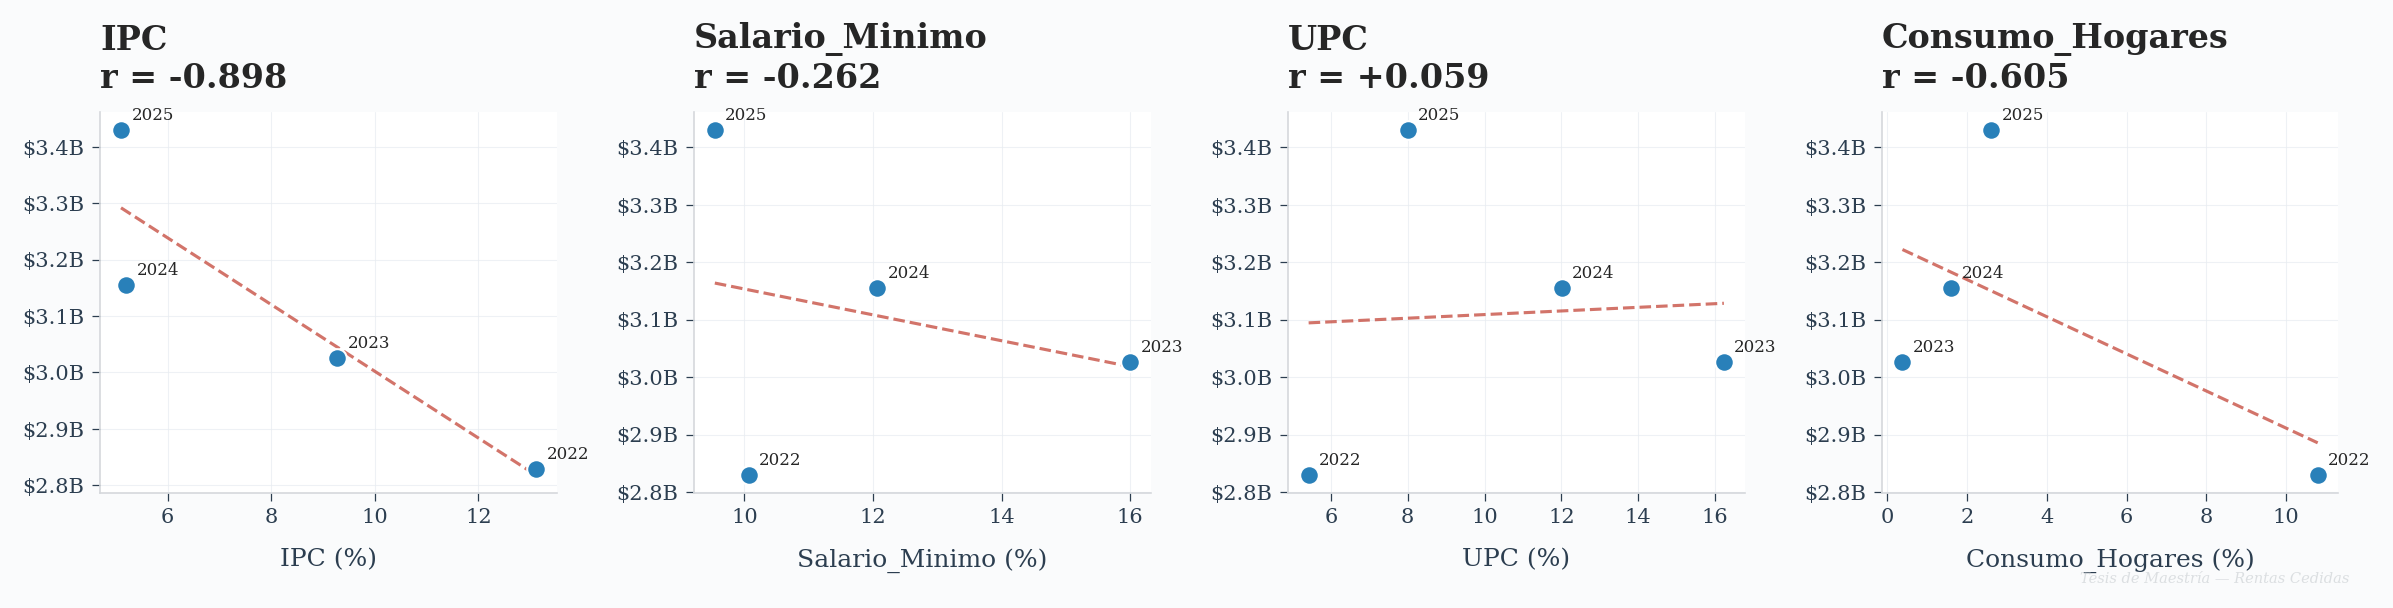

In [15]:
# ── 4.4 Correlación con variables macro ──────────────────────────
# Construir DataFrame macro anual
macro_df = pd.DataFrame(MACRO_DATA).T
macro_df.index.name = 'Año'

# Recaudo anual (sólo años completos con 12 meses)
recaudo_anual = df_mensual.groupby('Año')['Recaudo_Total'].agg(['sum', 'count'])
recaudo_anual = recaudo_anual[recaudo_anual['count'] == 12]  # sólo años completos
recaudo_anual = recaudo_anual.rename(columns={'sum': 'Recaudo_Anual'})

# Merge
tabla = macro_df.join(recaudo_anual[['Recaudo_Anual']], how='inner')

if len(tabla) >= 3:
    print("═" * 60)
    print("TABLA RECAUDO ANUAL vs MACRO")
    print("═" * 60)
    print(tabla.to_string())
    
    # Correlaciones
    print(f"\n{'─' * 60}")
    print("CORRELACIONES con Recaudo Anual")
    print(f"{'─' * 60}")
    for col in ['IPC', 'Salario_Minimo', 'UPC', 'Consumo_Hogares']:
        if col in tabla.columns:
            corr = tabla['Recaudo_Anual'].corr(tabla[col])
            fuerza = '★★★ Fuerte' if abs(corr) > 0.7 else '★★ Moderada' if abs(corr) > 0.4 else '★ Débil'
            print(f"  {col:<20} r = {corr:+.4f}  {fuerza}")
    
    # Scatter plots
    macro_vars = [c for c in ['IPC', 'Salario_Minimo', 'UPC', 'Consumo_Hogares'] if c in tabla.columns]
    n_vars = len(macro_vars)
    fig, axes = plt.subplots(1, n_vars, figsize=(4*n_vars, 4))
    if n_vars == 1:
        axes = [axes]
    
    for ax, var in zip(axes, macro_vars):
        ax.scatter(tabla[var], tabla['Recaudo_Anual'], color=C_TERTIARY,
                   s=80, zorder=3, edgecolors='white', linewidth=1)
        # Etiquetar puntos con año
        for idx, row in tabla.iterrows():
            ax.annotate(str(idx), (row[var], row['Recaudo_Anual']),
                        textcoords='offset points', xytext=(5, 5), fontsize=8)
        # Línea de tendencia
        if len(tabla) >= 3:
            z = np.polyfit(tabla[var], tabla['Recaudo_Anual'], 1)
            p = np.poly1d(z)
            x_line = np.linspace(tabla[var].min(), tabla[var].max(), 50)
            ax.plot(x_line, p(x_line), color=C_SECONDARY, ls='--', lw=1.5, alpha=0.7)
        
        corr_val = tabla['Recaudo_Anual'].corr(tabla[var])
        if _VIZ_THEME_LOADED:
            titulo_profesional(ax, f'{var}\nr = {corr_val:+.3f}')
            formato_pesos_eje(ax)
        else:
            ax.set_title(f'{var} (r={corr_val:+.3f})', fontweight='bold', fontsize=10)
        ax.set_xlabel(f'{var} (%)')
    
    plt.tight_layout()
    if _VIZ_THEME_LOADED:
        marca_agua(fig)
        guardar_figura(fig, '01_correlacion_macro_preview', OUTPUTS_FIGURES)
    plt.show()
else:
    print("⚠️ Insuficientes años completos para correlación macro.")


---
## Exportación de Datos Procesados

Se persisten los artefactos generados para consumo aguas abajo:
- `serie_mensual.csv` — Serie mensual con recaudo nominal, real, índice IPC y crecimiento YoY.
- Figuras en `outputs/figures/` en formato PNG a 300 DPI.


In [20]:
# ── Guardar serie mensual procesada ───────────────────────────────
cols_export = ['Recaudo_Total', 'Recaudo_Real', 'IPC_Indice', 'YoY', 'YoY_Real',
               'Año', 'Mes']
export = df_mensual[[c for c in cols_export if c in df_mensual.columns]].copy()
export.index.name = 'Fecha'

ruta_csv = DATA_PROCESSED / 'serie_mensual.csv'
export.to_csv(ruta_csv)
print(f"✅ Serie mensual guardada: {ruta_csv}")
print(f"   {len(export)} filas × {export.shape[1]} columnas")
print(f"   Columnas: {list(export.columns)}")

# Vista previa
print(f"\n📋 Vista previa:")
print(export.head(6).to_string())


✅ Serie mensual guardada: C:\Users\efren\Music\ESTRUCTURA DATOS RENTAS V2\data\processed\serie_mensual.csv
   51 filas × 3 columnas
   Columnas: ['Recaudo_Total', 'Año', 'Mes']

📋 Vista previa:
            Recaudo_Total   Año  Mes
Fecha                               
2021-10-01   2.246001e+11  2021   10
2021-11-01   2.223505e+11  2021   11
2021-12-01   2.145339e+11  2021   12
2022-01-01   3.042595e+11  2022    1
2022-02-01   1.799894e+11  2022    2
2022-03-01   2.766571e+11  2022    3


---
## Conclusiones y Fundamentos para el Modelado

### Hallazgos principales

1. **Estructura de datos.** El dataset comprende 149 648 registros transaccionales
   de 51 meses (Oct 2021 – Dic 2025), con 10 subgrupos fuente y 1 143 entidades
   aportantes. La columna `ValorRecaudo` requiere conversión a numérico; 27
   registros negativos corresponden a ajustes contables legítimos.

2. **Tendencia.** La serie mensual exhibe una tendencia creciente sostenida en
   valores nominales. Al deflactar con IPC, el crecimiento real es más moderado,
   evidenciando que parte del incremento nominal se explica por inflación.

3. **Estacionalidad.** Se confirma un patrón estacional de periodicidad 12 meses
   con picos recurrentes en enero y julio, coincidentes con el calendario de
   transferencias del SGSS. La fuerza de estacionalidad $F_s = 0.87$ cuantifica
   la alta significancia de este componente.

4. **Estacionariedad.** Las pruebas ADF y KPSS proporcionan el diagnóstico
   combinado de estacionariedad. Si la serie es no estacionaria, se requerirá
   al menos una diferenciación ($d \geq 1$) para el modelo SARIMAX.

5. **Autocorrelación.** Los correlogramas ACF/PACF revelan la estructura de
   dependencia temporal que parametrizará los órdenes $(p, d, q)(P, D, Q)_{12}$
   del modelo SARIMAX. Picos en lag 12 confirman la componente estacional.

6. **Distribución.** Las pruebas de normalidad (Jarque-Bera, Shapiro-Wilk)
   determinan si se requieren transformaciones (log, Box-Cox) antes del modelado.

7. **Concentración.** El análisis de Pareto revela alta concentración del recaudo
   (Gini = 0.46): 5 de los 10 subgrupos fuente explican $\geq$ 80 % del total,
   y las 5 principales entidades concentran el 48 % de los ingresos.

8. **Macro.** Las correlaciones preliminares con IPC, Salario Mínimo, UPC y
   Consumo de Hogares sugieren relaciones que serán formalizadas en el
   análisis de correlación macro (Notebook 03) y explotadas como
   regresores exógenos en SARIMAX y XGBoost.

### Implicaciones para la selección de modelos

| Hallazgo | Modelo favorecido |
|----------|-------------------|
| Estacionalidad fuerte ($F_s = 0.87$, $s=12$) | SARIMAX, Prophet |
| Tendencia + estacionalidad | SARIMAX con $(D=1)$, Prophet (piecewise linear) |
| Correlación con macro | SARIMAX, XGBoost |
| Posibles no-linealidades | XGBoost, LSTM |
| Serie corta (51 obs) | SARIMAX, Prophet (robustos con pocas observaciones) |

### Próximos pasos
→ **Notebook 02:** Análisis formal de estacionalidad (periodograma, test de Canova-Hansen).  
→ **Notebook 03:** Correlación cruzada con variables macroeconómicas.  
→ **Notebook 04:** Modelado SARIMAX con selección automática de órdenes.